In [5]:
from scipy.stats import spearmanr, pearsonr
#------------------------------------------------------------#
import numpy as np
import pickle
from matplotlib import pyplot as plt
#------------------------------------------------------------#
from utils import load_data as ld
from utils import load_EC as lec
from utils import colormaps as maps
from utils import correlations as cc
from utils import distance as di
from utils import interventional as IC
from utils import plot as pl
#------------------------------------------------------------#
from utils_izhi import topology as tp
from utils_izhi import izhikevic as iz
#------------------------------------------------------------#
# snn
from snn import channels as ut
#------------------------------------------------------------#
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
#------------------------------------------------------------#


In [122]:
#=================================================================================================#
# For Avenir font. To use it, you have to download the font-style files below.
# Comment the lines referred to fontManager if you don't need to set the font.
from matplotlib import font_manager, rcParams
font_file   = "/home/tentori/.local/avenir_ff/AvenirLTStd-Roman.otf"
font_file_b = "/home/tentori/.local/avenir_ff/AvenirLTStd-Black.otf"
font_file_c = "/home/tentori/.local/avenir_ff/AvenirLTStd-Book.otf"
font_manager.fontManager.addfont(font_file)
font_manager.fontManager.addfont(font_file_b)
font_manager.fontManager.addfont(font_file_c)
#------------------------------------------------------------#
rcParams['font.family']  = "Avenir LT Std"
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype']  = 42
#------------------------------------------------------------#
DIM = 25
plt.rcParams.update({'font.size': DIM,'axes.labelsize': DIM,'axes.titlesize': DIM,'xtick.labelsize': DIM,'ytick.labelsize': DIM})
#=================================================================================================#
# Colors
colorz    = ['#255D93','#5FA6D6','#B02106','#F24D33','#2C2C2C','#787878']
coldhot_cmap   = maps.create_cmaphot()
coldhot_cmap_r = maps.create_cmaphot_r()
#------------------------------------------------------------#
show_plot   = True
#------------------------------------------------------------#
from cmap import Colormap
def Cmap(cmap):
    return Colormap(cmap).to_mpl()
#------------------------------------------------------------#
def truncate_cmap(cmap, minval=0.0, maxval=0.8, n=256):
    from matplotlib.colors import Normalize, LinearSegmentedColormap
    return LinearSegmentedColormap.from_list( f'{cmap.name}_trunc', cmap(np.linspace(minval, maxval, n)) )
#------------------------------------------------------------#
def discrete_cmap(cmap_name='turbo', num_colors=25, minval=0., maxval=1):
    from matplotlib.colors import ListedColormap
    base = truncate_cmap(plt.get_cmap(cmap_name), minval=minval, maxval=maxval)
    return ListedColormap(base(np.linspace(0, 1, num_colors)))
cmap=truncate_cmap(plt.get_cmap('Blues'), minval=0.1, maxval=1)
#=================================================================================================#
# to create folder
def Set_Dir_Plots(path):
    import os
    if not os.path.exists(path):
        os.mkdir(path)
#=================================================================================================#


## Functions

In [7]:
def ic_save(_path_,ic,ic_pval,ic_pval_FDR,suffix=''):
    
    import pickle
    with open(_path_+'ks'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic, f)

    with open(_path_+'ks_pval'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic_pval, f)

    with open(_path_+'ks_pval_FDR'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic_pval_FDR, f)
        
def ic_load(_path_,suffix=''):
    
    with open(_path_+'ks'+suffix+'.pkl', 'rb') as f:
        ic = pickle.load(f)

    with open(_path_+'ks_pval'+suffix+'.pkl', 'rb') as f:
        ic_pval = pickle.load(f)
        
    with open(_path_+'ks_pval_FDR'+suffix+'.pkl', 'rb') as f:
        ic_pval_FDR = pickle.load(f)
        
    return ic, ic_pval, ic_pval_FDR

In [76]:
def stack_trials(channel, def_units, spikes, T_spont=0., DeltaT_sec=2., Ntrials=100, fs=1000, path_out=None, one=False):

    DeltaT  = int(DeltaT_sec * fs)
    n_units = len(def_units)  # n. stimulation channels
    
    # Global start times
    total_blocks = n_units * Ntrials
    T_starts     = int(T_spont * fs) + np.arange(total_blocks) * DeltaT
    
    spikeTimes_list = []
    spikeChannels_list = []

    block_idx = 0
    for trial in range(Ntrials):
        for unitID in def_units:
            block_spike_times = []
            block_spike_chans = []
            
            for ch in channel:
                t_ = spikes[unitID][trial][ch]
                t_ = t_[t_ < DeltaT]
                if t_.size == 0:
                    continue
                block_spike_times.append(t_)
                block_spike_chans.append(np.repeat(ch, t_.size))
    
            if block_spike_times:
                block_spike_times = np.concatenate(block_spike_times) + T_starts[block_idx]
                block_spike_chans = np.concatenate(block_spike_chans)
    
                spikeTimes_list.append(block_spike_times)
                spikeChannels_list.append(block_spike_chans)
    
            block_idx += 1
            
    # Concatenate all spike data
    if spikeTimes_list:
        spikeTimes    = np.concatenate(spikeTimes_list)
        spikeChannels = np.concatenate(spikeChannels_list)
    else:
        spikeTimes    = np.array([])
        spikeChannels = np.array([])
    
    # Final sort
    sort_idx      = np.argsort(spikeTimes)
    spikeTimes    = spikeTimes[sort_idx]
    spikeChannels = spikeChannels[sort_idx]
    
    if path_out is not None:
        data = np.column_stack((spikeChannels, spikeTimes.astype(int)))
        np.save(path_out + "spikeTimes_stimulation.npy", data)
    
    return spikeTimes, spikeChannels
#----------------------------------------------------------------------------------------------------------------------------#


In [77]:
def compute_spike_counts(spikes, binsize=0.02):
    """
    Estimate spike counts in bins of given size and return a T x N array.
    
    Parameters:
    spikes (numpy array): 2D array with first row as spike times in seconds and second row as neuron IDs.
    binsize (float):      Size of the bins in seconds. Default is 20ms.
    
    Returns:
    numpy array:          T x N array with spike counts, where T is the number of bins and N is the number of neurons.
    """
    # Extract spike times and neuron IDs
    spike_times = spikes[0]
    neuron_ids  = spikes[1].astype(int)
    
    # Determine the number of unique neurons
    unique_neurons = np.unique(neuron_ids)
    num_neurons    = len(unique_neurons)
    
    # Map neuron IDs to a continuous range starting from 0
    neuron_id_map     = {neuron_id: i for i, neuron_id in enumerate(unique_neurons)}
    mapped_neuron_ids = np.array([neuron_id_map[neuron_id] for neuron_id in neuron_ids])
    
    # Convert spike times to bin indices
    spike_bins   = (spike_times / binsize).astype(int)
    
    # Determine the number of bins
    num_bins     = spike_bins.max() + 1
    
    # Initialize the T x N array with zeros
    spike_counts = np.zeros((num_bins, num_neurons), dtype=int)
    
    # Use np.add.at to accumulate spike counts
    np.add.at(spike_counts, (spike_bins, mapped_neuron_ids), 1)
    
    return spike_counts

In [78]:
def sort_units_with_distance(i, channel, pos, def_units, def_chans):
    
    def eucl_dist(a1, a2):
        return np.sqrt( (a1[0]-a2[0])*(a1[0]-a2[0]) + (a1[1]-a2[1])*(a1[1]-a2[1]) )
    
    ch = channel[i]

    # dist between ch and stim. chans.
    distances = np.zeros(len(def_units))
    for idx in range(len(def_units)):
        id1 = np.where(channel==def_chans[idx])[0][0]
        id2 = np.where(channel==ch)[0][0]
        distances[idx] = eucl_dist(pos[id1,:],pos[id2,:])
    
    # stim. channels ordered in increasing distance
    L = np.argsort(distances)
    return L[::-1], distances[L[::-1]]

def despine_all(fig):
    for ax in fig.axes:
        for side in ("left", "right", "top", "bottom"):
            ax.spines[side].set_visible(False)
        ax.tick_params(left=False, right=False, top=False, bottom=False)

### plot EC hists

In [11]:
def plot_PN_links(mats, mats2, labs, rangesP, thresholdsP, rangesN, thresholdsN):
    fig,axs=plt.subplots(1,3,figsize=(20,4))
    
    for ax, mat, mat2, th, lab, lim in zip(axs, mats, mats2, thresholdsP, labs, rangesP):
        h  = ax.hist(np.log10(mat[mat>0]),100, lim,  color='tab:blue', density=False, label='no-sign')
        h2 = ax.hist(np.log10(mat2[mat2>0]),100, lim, color='tab:red', density=False, label='sign')
        ax.plot([th,th],[0,np.max(h[0])],'--k',lw=1)
        
        ax.set_xlabel(lab)
        pl.set_format(ax=ax, DIM=DIM, pwr_x_max=2)
        ax.legend(fontsize=DIM, ncol=1, loc='upper center', bbox_to_anchor=(0.5, 1.5), labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    fig.suptitle('positive links',y=1.5)

    # limiting negative values
    fig,axs=plt.subplots(1,3,figsize=(20,4))
    
    for ax, mat, mat2, th, lab, lim in zip(axs, mats, mats2, thresholdsN, labs, rangesN):
        h  = ax.hist(np.log10(-mat[(mat<0)]),100,lim, color='tab:blue', density=False, label='no-sign')
        h2 = ax.hist(np.log10(-mat2[(mat2<0)]),100,lim,color='tab:red', density=False, label='sign')
        ax.plot([th,th],[0,np.max(h[0])],'--k',lw=1)
        
        ax.set_xlabel(lab)
        ax.legend(fontsize=DIM, ncol=1, loc='upper center', bbox_to_anchor=(0.5, 1.5), labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
        pl.set_format(ax=ax, DIM=DIM, pwr_x_max=2, pwr_x_min=-2)
        
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    fig.suptitle('negative links',y=1.5)


In [79]:
def plot_counts(i_rec, sorted_units, indices, counts_dict, bin_sz=0.005, pre_start = 0.5, post_stop=1.505, stim0=1.,stim_end=1.005, 
                figsize=(5,6), outf:str=None, show_plot=False):
    
    fig,ax = plt.subplots(figsize=figsize)

    # stack trials for each stim unit/channel
    trials = (counts_dict[0][0])[:,i_rec]
    for i_unit in sorted_units:
        if i_unit!=0:
            nstart=0
        else:
            nstart=1
        for n in range(nstart,Ntrials):
            trials = np.vstack([ trials, (counts_dict[i_unit][n])[:,i_rec]])
            
    # from bins to time
    t    = np.arange(trials.shape[1])*bin_sz

    condition = (t>=pre_start) & (t<post_stop)
    ax.imshow(trials[:,condition], aspect='auto', cmap=Cmap('lapaz'), vmin=0, vmax=0.001)
    
    # separate trials related to different stim channels with a white line
    for i, i_unit in enumerate(sorted_units):
        ax.plot([0,int((post_stop-pre_start)/bin_sz)], [i*Ntrials,i*Ntrials], color='white',lw=2)
    
    # white stripe where stimulation occurs    
    ax.fill_between([int((stim0-pre_start)/bin_sz),int((stim_end-pre_start)/bin_sz)], 0, len(def_units)*Ntrials, color='red',alpha=1)

    '''# label stim channels (sorted by distance from rec channel)
    k=0
    for idx in sorted_units:
        plt.text(int((stim0-pre_start)/bin_sz)+6., (k*Ntrials)+Ntrials/2-20, str(int(indices[idx])), color='black',
         fontsize=DIM-20, ha='center', va='center')
        k+=1'''

    # set limits to constrain lines
    ax.set_xlim(0,int((post_stop-pre_start)/bin_sz))
    ax.set_ylim(0,Ntrials*len(indices))

    # 
    despine_all(fig)
    ax.set_xticks([])
    ax.set_yticks([])

    fig.set_facecolor('none')
    plt.title('channel '+str(i_rec)+ ' response',fontsize=DIM)

    if outf:
        plt.savefig(outf, bbox_inches='tight')
        if show_plot==False:
            plt.close()
            

### plot channel maps

In [72]:
def plot_map_rec(pos_, col_list, channel, def_chans, indices, array_col, cmap=None, cbar_label='', title=None, dotcolor='lightgrey',
                 dotsize=4.5, starsize = 1350, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2, 
                 figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    
    pos = pos_[:,:]/1000
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    scatter_rec = ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', c=col_list, edgecolor='white',
                             label='rec.', cmap=cmap, zorder=0)
    if cmap is not None:
        cbar        = fig.colorbar(scatter_rec, ax=ax, label=cbar_label)
    
    # stimulation channels
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], c=array_col, edgecolor='white', s=starsize, marker='*', alpha=1, zorder=1,
                         label='stim.')
    
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM-5, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    if title:
        ax.set_title(title)

    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [73]:
def plot_channel_map_3(pos_, rec_list, col_list, channel, def_chans, indices, array_col, rec_color='tab:blue', cmap=None, cbar_label='', title=None, dotcolor='lightgrey',
                       dotsize=4.5, starsize = 1350, starsize_center = 50, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2,
                       rec_text=True, figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    # optimized for small size plots also
    pos = pos_[:,:]/1000
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', color=dotcolor, edgecolor='white', zorder=0) #, label='rec. channels')

    # Highlight specific recording channels
    ax.scatter(pos[rec_list, 0], pos[rec_list, 1], s=starsize, c=rec_color, lw=0.4, marker='o',  edgecolor='black', label=f'rec. channels', zorder=0)

    # stimulation channels
    if cmap is not None:
        vmin, vmax = np.percentile(array_col, [2.5, 97.5])
    else:
        vmin, vmax = (None, None)
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], cmap=cmap, vmin=vmin, vmax=vmax, c=array_col, 
                         edgecolor='white', s=starsize, marker='*', alpha=1, zorder=1, label='stim. channels')
    if starsize_center is not None:
        ax.scatter(pos[indices, 0], pos[indices, 1], color='white', edgecolor='white', linewidths=0.1, 
                   s=starsize_center, marker='*', alpha=1, zorder=3)
    # cmap
    if cmap is not None:
        cbar = fig.colorbar(scatter, ax=ax, label=cbar_label)
    else:
        pass
            
    # labels for rec channels 
    if rec_text is True:
        a = 0
        for i_rec, i_col in zip(rec_list, col_list):
            x = pos[channel == channel[i_rec], 0][0];    y = pos[channel == channel[i_rec], 1][0]
    
            dx, dy = -420, 180
                
            ax.text(x + dx/1000, y + dy/1000, str(i_rec),fontdict=dict(color='k', alpha=1, size=text_dim))
            a += 1
    
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    if title:
        ax.set_title(title)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [74]:
def plot_channel_map_2(pos_, channel, def_chans, indices, array_col, cmap=None, cbar_label='', title=None, dotcolor='lightgrey',
                       dotsize=4.5, starsize = 1350, starsize_center = 50, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2,
                       figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    # optimized for small size plots also
    pos = pos_[:,:]/1000
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', color=dotcolor,edgecolor='white',label='rec. channels', zorder=0)
    
    # stimulation channels
    if cmap is not None:
        vmin, vmax = np.percentile(array_col, [2.5, 97.5])
    else:
        vmin, vmax = (None, None)
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], cmap=cmap, vmin=vmin, vmax=vmax, c=array_col, 
                         edgecolor='white', s=starsize, marker='*', alpha=1, zorder=1, label='stim. channels')
    if starsize_center is not None:
        ax.scatter(pos[indices, 0], pos[indices, 1], color='white', edgecolor='white', linewidths=0.1, 
                   s=starsize_center, marker='*', alpha=1, zorder=3)
    # cmap
    if cmap is not None:
        cbar = fig.colorbar(scatter, ax=ax, label=cbar_label)
    else:
        pass
    
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    if title:
        ax.set_title(title)
        
    fig.set_facecolor('none')
    del pos
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [16]:
def plot_mat_aspect(mat, cmap='viridis', title=None, xlabel='time (s)', ylabel='channel ID', cbarlabel='spike count', vmin=None, vmax=None,
                    inevert_y : bool = True, figsize=(15,5), outf : str = None, show_plot = True):
    mat_max = np.max(mat.flatten())
    #vmin=0.6; vmax=0.1
    if vmin==None or vmax==None:
        vmin,vmax = np.percentile(mat.flatten()/mat_max,[2.5,97.5])
    else:
        pass
    fig,ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat/mat_max, aspect='auto', vmin=vmin,vmax=vmax, cmap=cmap)
    print(vmin,vmax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        plt.title(title)
    cbar = fig.colorbar(im, ax=ax, label=cbarlabel)
    if inevert_y:
        ax.invert_yaxis()
    
    if outf:
        plt.savefig(outf, bbox_inches='tight')
    
    if show_plot == False:
        plt.close()
    else:
        plt.show()

In [80]:
def plot_scatter(ic_mat, ec_mat, zeroExp=-11, log=False, xlabel='IC', ylabel='EC', title=None, dotsize=0.1, 
                 cmap=None, edgecolor=None, linewidths=0.2, regcolor='tab:red', dotcolor='tab:blue', reg_line=False, show_corr=True,
                 xmin=None, xmax=None, ymin=None, ymax=None, ax=None, alpha=1, figsize=(3.5,3), outf=None, show_plot=False):
    import seaborn as sns
    from scipy.stats import pearsonr, spearmanr, gaussian_kde
    ic_vec = ic_mat.flatten()
    if log:
        ec_vec = np.log10(ec_mat.flatten()+10**zeroExp)
        x=ic_vec[ec_mat.flatten()!=0]
        y=ec_vec[ec_mat.flatten()!=0]
    else:
        ec_vec = ec_mat.flatten()
        x=ic_vec
        y=ec_vec

    if ymin is not None and ymax is not None:
        y_ = np.copy(y)        
        x = x[(y_>=ymin) & (y_<ymax)]
        y = y_[(y_>=ymin) & (y_<ymax)]
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
        
    if cmap:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        vmax = np.max(z); vmin = vmax; 
        # Plot with density-based color
        scatter = ax.scatter(x, y, c=z, s=dotsize, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label(r'density', fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)
    else:
        ax.scatter(x, y, s=dotsize, c=dotcolor, edgecolor=edgecolor, linewidths=linewidths, alpha=alpha)

    if reg_line:
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
    
    if show_corr:
        cp = np.round(pearsonr(ic_vec,ec_vec)[0],2)
        cs = np.round(spearmanr(ic_vec,ec_vec)[0],2)
        pval_p = pearsonr(ic_vec,ec_vec)[1]
        pval_s = spearmanr(ic_vec,ec_vec)[1]
        if title:
            ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
    else:
        if title:
            ax.set_title(title)
        
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin,ymax)
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin,xmax)
        
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel);

    if cmap:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, pwr_cbar_min=-2, pwr_cbar_max=2,  DIM = DIM)
    else:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = None, DIM = DIM)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [81]:
def plot_scatterColor(x_mat, y_mat, color_vec=None, xlabel='IC', ylabel='EC', title=None, dotsize=0.1, cbar_label='',
                      cmap=None, edgecolor=None, linewidths=0.2, show_corr=True, alpha=0.7, figsize=(3.5,3),
                      vmin_color=None, vmax_color=None, xmin=None, xmax=None, ymin=None, ymax=None, ax=None, outf=None, show_plot=False):
    import seaborn as sns
    from scipy.stats import pearsonr, spearmanr, gaussian_kde

    if color_vec is not None:
        c_vec=color_vec.flatten()
    x = x_mat.flatten()
    y = y_mat.flatten()

    if ymin is not None and ymax is not None:
        y_ = np.copy(y)        
        x = x[(y_>=ymin) & (y_<ymax)]
        y = y_[(y_>=ymin) & (y_<ymax)]
        c_vec = c_vec[(y_>=ymin) & (y_<ymax)]
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
        
    if color_vec is None:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        vmax = np.max(z); vmin = vmax; 
        # Plot with density-based color
        scatter = ax.scatter(x, y, c=z, s=dotsize, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label('density', fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)
    else:
        scatter = ax.scatter(x, y, s=dotsize, c=c_vec, vmin=vmin_color, vmax=vmax_color, edgecolor=edgecolor, linewidths=0.01, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label(cbar_label, fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)

    if show_corr:
        cp = np.round(pearsonr(x,y)[0],2)
        cs = np.round(spearmanr(x,y)[0],2)
        pval_p = pearsonr(x,y)[1]
        pval_s = spearmanr(x,y)[1]
        if title:
            ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
    else:
        if title:
            ax.set_title(title)
    
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin,ymax)
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin,xmax)
        
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel);

    if cmap:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, pwr_cbar_min=-2, pwr_cbar_max=2,  DIM = DIM)
    else:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = None, DIM = DIM)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [142]:
def plot_traces(i_rec, sorted_units, indices, counts_dict, col_post, col_n, bin_sz=0.01, n_ampli=1, 
                pre_start=0.49, pre_stop=0.99, post_start=1+0.004, post_stop=1.504, stim0=1, stimEnd=1+0.003, figsize=(5,6), outf:str=None, show_plot=False):

    fig,ax = plt.subplots(figsize=figsize)
    
    for i,i_unit in enumerate(sorted_units):

        # put together trials for each stimulation from i_unit, for fixed i_rec rec-channel
        trials = (counts_dict[i_unit][0])[:,i_rec]
        for n in range(1,Ntrials):
            trials = np.vstack([ trials, (counts_dict[i_unit][n])[:,i_rec]])

        # average spike counts across trials, for each i_unit
        mean = np.sum(trials,axis=0)/Ntrials 
        t    = np.arange(len(mean))*bin_sz   

        # zero amplitude of each trial
        ax.plot([pre_start,post_stop], [i,i], color='black',lw=0.1)

        # pulses of stimulation (the exact ones)
        for k in range(2):
            ax.plot([stim0+k*0.003,stim0+k*0.003], [i,i+0.3], color='black',lw=0.1)
        m_pre   = np.mean(mean[(t>pre_start) & (t<=pre_stop)])
        max_pre = np.max(np.abs(mean[(t>pre_start) & (t<=pre_stop)]))
        # pre and post traces
        y_pre  = (mean[(t>pre_start) & (t<=pre_stop)]   - m_pre) / max_pre*0.2 * n_ampli
        y_post = (mean[(t>=post_start) & (t<post_stop)] - m_pre) / max_pre*0.2 * n_ampli
        ax.plot(t[(t>pre_start) & (t<=pre_stop)],   y_pre  + i, color=col_n,       lw=2, alpha=1)
        ax.plot(t[(t>=post_start) & (t<post_stop)], y_post + i, color=col_post[i], lw=2, alpha=1)        

    despine_all(fig)
    
    # y-ticks: stim units
    ax.set_yticks(np.arange(len(indices)))
    ax.set_yticklabels(indices[sorted_units], fontsize=DIM-10)
    ax.set_ylabel('stim. channel',fontsize=DIM)
    
    # no x-ticks
    ax.set_xticks([])
    
    fig.set_facecolor('none')
    plt.title('channel '+str(i_rec)+ ' response',fontsize=DIM)
    
    if outf:
        plt.savefig(outf, bbox_inches='tight')
        if show_plot==False:
            plt.close()


In [83]:
def plot_stimulations(i, channel, pos, def_units, def_chans, def_spikes, stim_start, Delta_pre, Tmax, stim_stop, Delta_post, 
                      Ntrials=200, outf:str=None,show_plot=True):
    def eucl_dist(a1, a2):
        return np.sqrt( (a1[0]-a2[0])*(a1[0]-a2[0]) + (a1[1]-a2[1])*(a1[1]-a2[1]) )
    
    DIM = 95
    ch = channel[i]
    
    fig,ax = plt.subplots(figsize=(18,30))
    
    plt.plot([(stim_start-Delta_pre-Tmax)/20000,(stim_stop+Delta_post+Tmax)/20000],
                 [0,0], color='black',lw=0.2)
    
    distances = np.zeros(len(def_units))
    for idx in range(len(def_units)):
        id1 = np.where(channel==def_chans[idx])[0][0]
        id2 = np.where(channel==ch)[0][0]
        distances[idx] = eucl_dist(pos[id1,:],pos[id2,:])
    
    L = np.argsort(distances)
    
    k = 0
    for idx in L[::-1]:
        uID           = def_units[idx]
        stimulating_C = def_chans[idx]
        
        #print(idx,uID,stimulating_C,indices[idx])
        
        plt.plot([(stim_start-Delta_pre-Tmax)/20000,(stim_stop+Delta_post+Tmax)/20000],
                 [(k+1)*Ntrials,(k+1)*Ntrials], color='black',lw=0.2)
        
        for i_trial in range(Ntrials):
            
            t = def_spikes[uID][i_trial][ch]
            
            t_pre  = t[np.logical_and(t>=stim_start-Delta_pre-Tmax,t<stim_start-Delta_pre)]
            t_post = t[np.logical_and(t>stim_stop+Delta_post,t<=stim_stop+Delta_post+Tmax)]

            plt.scatter(t_pre/20000,  np.ones(len(t_pre)) * i_trial  + k*Ntrials, 
                        s=6, marker = '.', c='black')#, edgecolor='white', linewidths=0.2)
            plt.scatter(t_post/20000, np.ones(len(t_post)) * i_trial + k*Ntrials, 
                        s=6, marker = '.', c='black')#, edgecolor='white', linewidths=0.2)
            
            del t, t_pre, t_post
            
        k=k+1
            
    pl.set_format(ax=ax,DIM=DIM,pwr_x_min=-2)
    k=0
    for idx in L[::-1]:
        plt.text((stim_start + stim_stop) / 40000, (k + 0.5) * Ntrials, str(int(indices[idx])), 
         fontsize=55, ha='center', va='center')
        k+=1

    ax.set_yticks([])
    
    plt.fill_between([stim_start/20000,stim_stop/20000], 0, Ntrials*len(def_units), color='white',alpha=0.1)
    plt.title('channel '+str(ch)+ ' response',fontsize=DIM)

    ax.set_ylabel('trials per stim.channel',fontsize=DIM)
    ax.set_xlabel('time (s)',fontsize=DIM)
    
    if outf:
        plt.savefig(outf, bbox_inches='tight')
        if show_plot==False:
            plt.close()
    
    del DIM


### plot KS

In [21]:
def plot_ks(i_rec, sorted_units, indices, counts_dict, col_post, col_n, bin_sz=0.01, 
            figsize=(15,20), outf:str=None, show_plot=False):

    fig,axs_ = plt.subplots(5,4,figsize=figsize)
    axs = axs_.ravel()
    
    for i,i_unit in enumerate(sorted_units):

        ax = axs[i]
        
        # put together trials for each stimulation from i_unit, for fixed i_rec rec-channel
        trials = (counts_dict[i_unit][0])[:,i_rec]
        for n in range(1,Ntrials):
            trials = np.vstack([ trials, (counts_dict[i_unit][n])[:,i_rec]])

        # time in seconds
        t    = np.arange(trials.shape[1])*bin_sz

        pre_cond = (t>=0.4) & (t<0.9)
        pre = trials[:,pre_cond].flatten()

        post_cond = (t>1.12) & (t<=1.62)
        post = trials[:,post_cond].flatten()

        x_pre = np.sort(pre)
        F_pre = np.arange(1, len(pre)+1) / len(pre)

        x_post = np.sort(post)
        F_post = np.arange(1, len(post)+1) / len(post)
        
        # pre and post traces
        ax.plot(x_pre,  F_pre,  '-',  color='tab:blue', lw=4.5)
        ax.plot(x_post, F_post, '--', color='tab:red',  lw=3)

        ax.set_ylim(0,1.2)
        ax.set_xlabel('spike count',fontsize=DIM)
        ax.set_ylabel('cdf',fontsize=DIM)
        ax.set_title(f'stim. chan. {indices[i_unit]}')
        pl.set_format(ax=ax,DIM=DIM,pwr_x_min=-2,pwr_y_min=-2)
        
    fig.set_facecolor('none')
    fig.suptitle('channel '+str(i_rec)+ ' response\n'+f'binsize {int(bin_sz*1000)} ms',fontsize=DIM)
    fig.subplots_adjust(wspace=0.9, hspace=0.9)
    
    if outf:
        plt.savefig(outf, bbox_inches='tight')
        if show_plot==False:
            plt.close()


## Simulation parameters

In [22]:
#=================================================================================================#
#----------------------------------------#
# SIMULATION
regime       = 'RS-IB'
deltat       = 1
_tau_R       = 500.
_g_I         = 1.
_beta_E      = 0.1
_gain_AMPA   = 1.
#----------------------------------------#
# TOPOLOGY
dist_rule    = 'EDR'
nNeurons     = 1000
local_II     = False
#=================================================================================================#
# folder – network 1
modules     = '2'
folder      = f'network{nNeurons}_{modules}mod_{dist_rule}_noII__tauR_{_tau_R}__g_I_{_g_I}__betaE_{_beta_E}__gain_AMPA_{_gain_AMPA}/'
folder_net  = f'network{nNeurons}_{modules}mod_{dist_rule}_noII/'
#        – network 2
modules     = '1'
folder2     = f'network{nNeurons}_{modules}mod_{dist_rule}_noII__tauR_{_tau_R}__g_I_{_g_I}__betaE_{_beta_E}__gain_AMPA_{_gain_AMPA}/'
folder_net2 = f'network{nNeurons}_{modules}mod_{dist_rule}_noII/'

print(folder)
print(folder2)

network1000_2mod_EDR_noII__tauR_500.0__g_I_1.0__betaE_0.1__gain_AMPA_1.0/
network1000_1mod_EDR_noII__tauR_500.0__g_I_1.0__betaE_0.1__gain_AMPA_1.0/


## Paths

In [23]:
# =================================================================================================#
# data generation paths

path_results = './Data_SNNmodel/'
# ------------------------------------------------------------#
# 1 generated connectivity
path_network     = path_results+'Generated_network/'+folder_net+'Data/'
path_network2    = path_results+'Generated_network/'+folder_net2+'Data/'
#------------------------------------------------------------#
# 2 spontaneous activity
spont_out    = path_results+'Spontaneous_activity/'+folder
spont_data   = spont_out+'Data/'
spont_out2    = path_results+'Spontaneous_activity/'+folder2
spont_data2   = spont_out2+'Data/'
#------------------------------------------------------------#
# 3 evoked activity
evoked_out   = path_results+'Evoked_activity/'+folder
evoked_data  = evoked_out+'Data/'
evoked_out2   = path_results+'Evoked_activity/'+folder2
evoked_data2  = evoked_out2+'Data/'
#------------------------------------------------------------#
# 3.1 interventional connectivity
path_IC_data     = evoked_out+'IC_Data/'
path_ICbin_data  = evoked_out+'IC_bin_Data/'
path_IC_data2    = evoked_out2+'IC_Data/'
path_ICbin_data2 = evoked_out2+'IC_bin_Data/'
# ------------------------------------------------------------#
# results paths
res_out      = 'Results_imgs/'
path_imgs    = res_out+'Fig2_model/'
# ------------------------------------------------------------#
# create folders
Set_Dir_Plots(res_out)
Set_Dir_Plots(path_imgs)
#------------------------------------------------------------#
print(path_imgs)

Results_imgs/Fig2_model/


## Network and simulation parameters

In [25]:
# NETWORK 1
#---------------------------------------------------------------------------------------------------------------#
# load net dictionary – from evoked activity folder
with open(evoked_data+'net.pkl', 'rb') as file:
    net = pickle.load(file)

# STIMULATION CHANNELS – from network gen folder
chans  = np.load(path_network + 'def_chans.npy')
idxs = net['ntypes'][chans]
idxs[chans==614]=False
def_chans  = chans[idxs]
def_units  = np.load(path_network + 'def_units.npy')[idxs]
stim_chans = np.copy(def_chans)
indices    = np.copy(def_chans)
#---------------------------------------------------------------------------------------------------------------#

# NETWORK 2
#---------------------------------------------------------------------------------------------------------------#
# load net dictionary – from evoked activity folder
with open(evoked_data2+'net.pkl', 'rb') as file:
    net2 = pickle.load(file)

# STIMULATION CHANNELS – from network gen folder
chans2  = np.load(path_network2 + 'def_chans.npy')
idxs2 = net2['ntypes'][chans2]
idxs2[chans2==614]=False
def_chans2  = chans2[idxs2]
def_units2  = np.load(path_network2 + 'def_units.npy')[idxs2]
stim_chans2 = np.copy(def_chans2)
indices2    = np.copy(def_chans2)
#---------------------------------------------------------------------------------------------------------------#


In [29]:
#================================================================================================================#
#                                            1.2) NETWORK PARAMETERS
#================================================================================================================#
deltat=1
fs = 1000

#---------------------------------------------------------------------------------------------------------------#
# SPONTANEOUS

T_spont=10 # for EC
alpha_TE=0.05
load_sign=True
#---------------------------------------------------------------------------------------------------------------#

#---------------------------------------------------------------------------------------------------------------#
# EVOKED
Ntrials        = 200
stim_start_sec = 1
dT_trial_sec   = 2
dT_trial       = dT_trial_sec*net['fs']
Ttrial_block   = dT_trial_sec*Ntrials    # one trial block duration in sec (meaning 1 trial per each stim channel)
IPI_ms         = 3
n_pulses       = 2
Tstim_ms       = IPI_ms*(n_pulses-1)+1
#---------------------------------------------------------------------------------------------------------------#


In [60]:
#---------------------------------------------------------------------------------------------------------------#
# IC PARAMETERS

IC_compute = True
load_def_spikes = IC_compute

N_JOBS = 1
# pre– and post–stimulation time windows
Tmax_ms    = 300
Tmax       = int(round(Tmax_ms / net['deltat']))
Delta_post = 0
Delta_pre  = 0
# binning size for spike count
dT_ms      = 20
dT         = int(round(dT_ms / net['deltat']))
Nbins      = max(1, Tmax // dT)
# stim. window-length
stim_start = int(round(1.0 * net['fs']))                   # onset of the stimulus
Tstim_steps = int(round(Tstim_ms / net['deltat']))         # end of the stimulus
stim_stop  = stim_start + Tstim_steps
# P-value threshold for EC and IC
alpha_th   = 0.05
#---------------------------------------------------------------------------------------------------------------#


# 1. Data load

## 1.1 Map features load

In [35]:
# map features
channel = net['channel']
pos     = net['pos']*1000
cluster = net['channel']

In [30]:
# map features
channel2 = net2['channel']
pos2     = net2['pos']*1000
cluster2 = net2['channel']

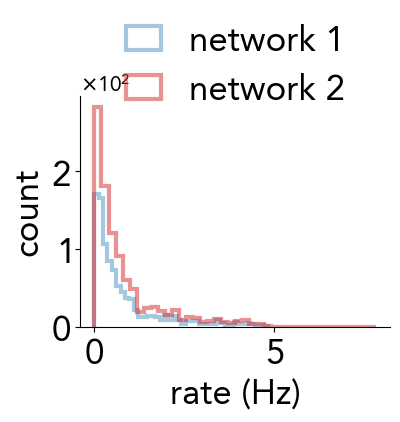

In [32]:
#------------------------------------------------------------------------------------------------------------#
# load rate – from spontaneous activity
rate=np.loadtxt(spont_data+'rates.txt',unpack=True,usecols=(0))
rate2=np.loadtxt(spont_data2+'rates.txt',unpack=True,usecols=(0))

#------------------------------------------------------------------------------------------------------------#
# PLOT: rate 
fig,ax = plt.subplots(figsize=(4,3))
h=ax.hist(rate, 40, [0, np.max(rate)], histtype='step', color='tab:blue',alpha = 0.4,  lw=3, label='network 1')
h=ax.hist(rate, 40, [0, np.max(rate2)], histtype='step', color='tab:red',alpha = 0.5,  lw=3, label='network 2')
ax.set_xlabel('rate (Hz)')
ax.set_ylabel('count')
ax.legend(ncol=1, loc='upper center', bbox_to_anchor=(0.5, 1.45), labelspacing=0.4, handletextpad=0.8, handlelength = 1., frameon=False) 
pl.set_format(ax=ax, DIM = DIM, pwr_x_max=3,pwr_x_min=-2, pwr_y_max=2, pwr_y_min=-2)
plt.savefig(path_imgs + 'spontaneous_rates.png', bbox_inches='tight')
if show_plot==False:
    plt.close()
#------------------------------------------------------------------------------------------------------------#

### 1.1.2 evoked activity experimental block – features load

In [ ]:
#================================================================================================================#
#                                   5) EVOKED CONNECTIVITY
#================================================================================================================#

#------------------------------------------------------------------------------------------------------------#
# load def_spikes
load_def_spikes=True
if load_def_spikes:
    with open(evoked_data + 'def_spikes.pkl', 'rb') as file:
        def_spikes = pickle.load(file)
else:
    pass

# Load evoked-activity
spikeTimes, spikeChannels = stack_trials(channel, def_units, def_spikes, T_spont=0, DeltaT_sec=2., Ntrials=Ntrials)
fs=1000
spikes=(spikeTimes/fs,spikeChannels.astype(int))


In [39]:
# NETWORK 2
#------------------------------------------------------------------------------------------------------------#
# load def_spikes
load_def_spikes=True
if load_def_spikes:
    with open(evoked_data2 + 'def_spikes.pkl', 'rb') as file:
        def_spikes2 = pickle.load(file)
else:
    pass

# Load evoked-activity
spikeTimes2, spikeChannels2 = stack_trials(channel2, def_units2, def_spikes2, T_spont=0, DeltaT_sec=2., Ntrials=Ntrials)
fs=1000
spikes2=(spikeTimes2/fs,spikeChannels2.astype(int))


In [49]:
# compute spike counts
bin_sz   = 0.01
s_counts = compute_spike_counts(spikes, binsize=bin_sz)
s_counts2 = compute_spike_counts(spikes2, binsize=bin_sz)

Text(0.5, 1.0, 'Network 2')

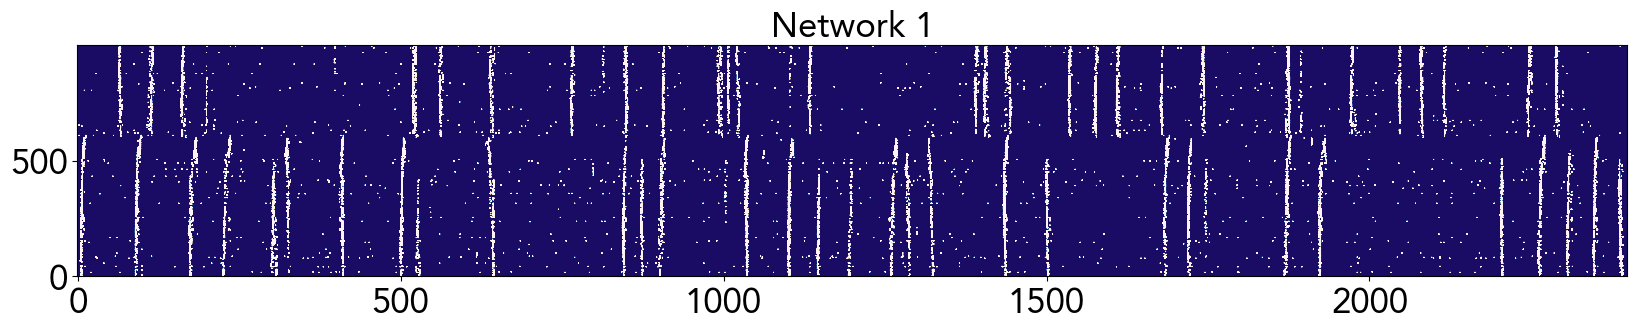

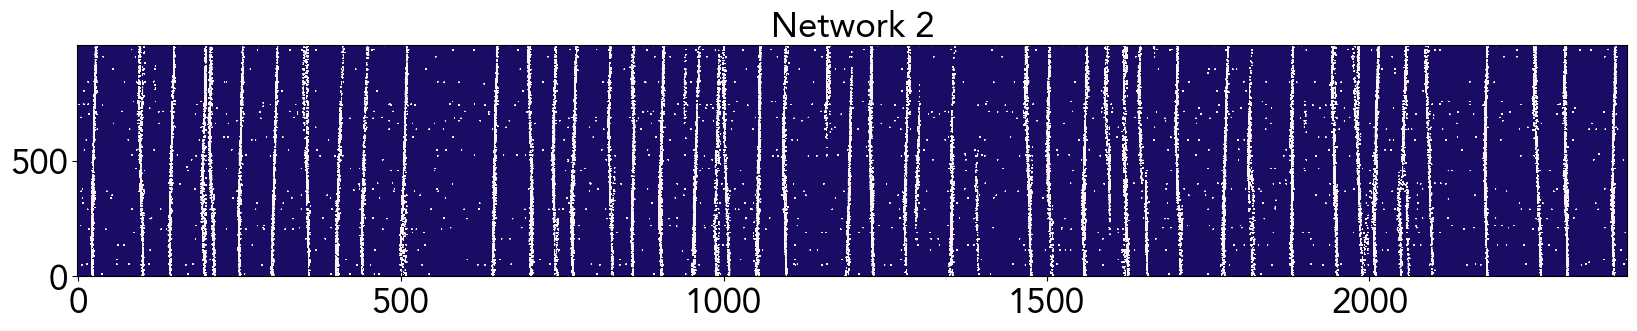

In [50]:
# network 1
t    = np.arange(s_counts.shape[0])*bin_sz 
fig,ax = plt.subplots(figsize=(20,3))
ax.imshow(s_counts[(t<24)].T,aspect='auto', cmap=Cmap('lapaz'),vmin=0, vmax=0.01,)
ax.invert_yaxis()
ax.set_title('Network 1')

# network 2
t    = np.arange(s_counts2.shape[0])*bin_sz 
fig,ax = plt.subplots(figsize=(20,3))
ax.imshow(s_counts2[(t<24)].T,aspect='auto', cmap=Cmap('lapaz'),vmin=0, vmax=0.01,)
ax.invert_yaxis()
ax.set_title('Network 2')

## 1.2 effective connectivity (EC)

TE, SC, XCov computed from 30 mins spontaneous activity.

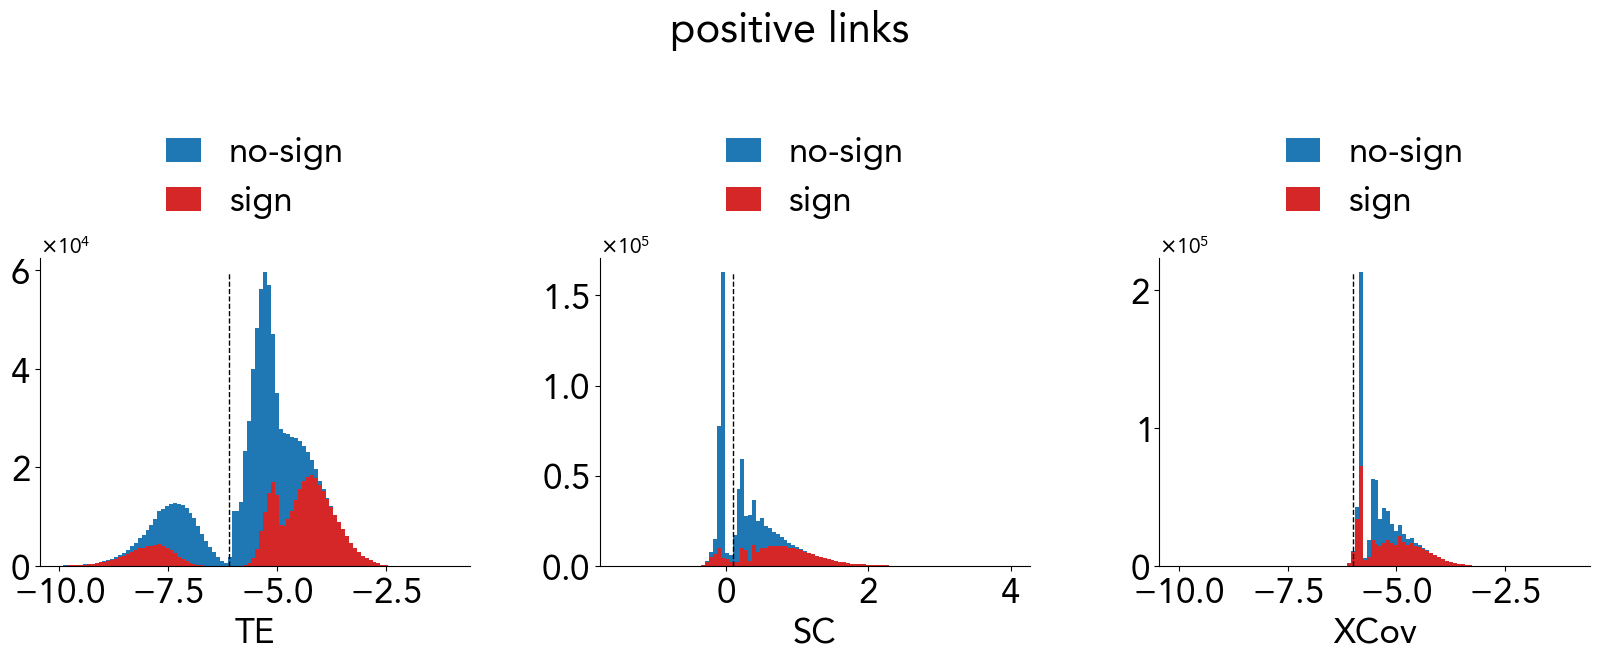

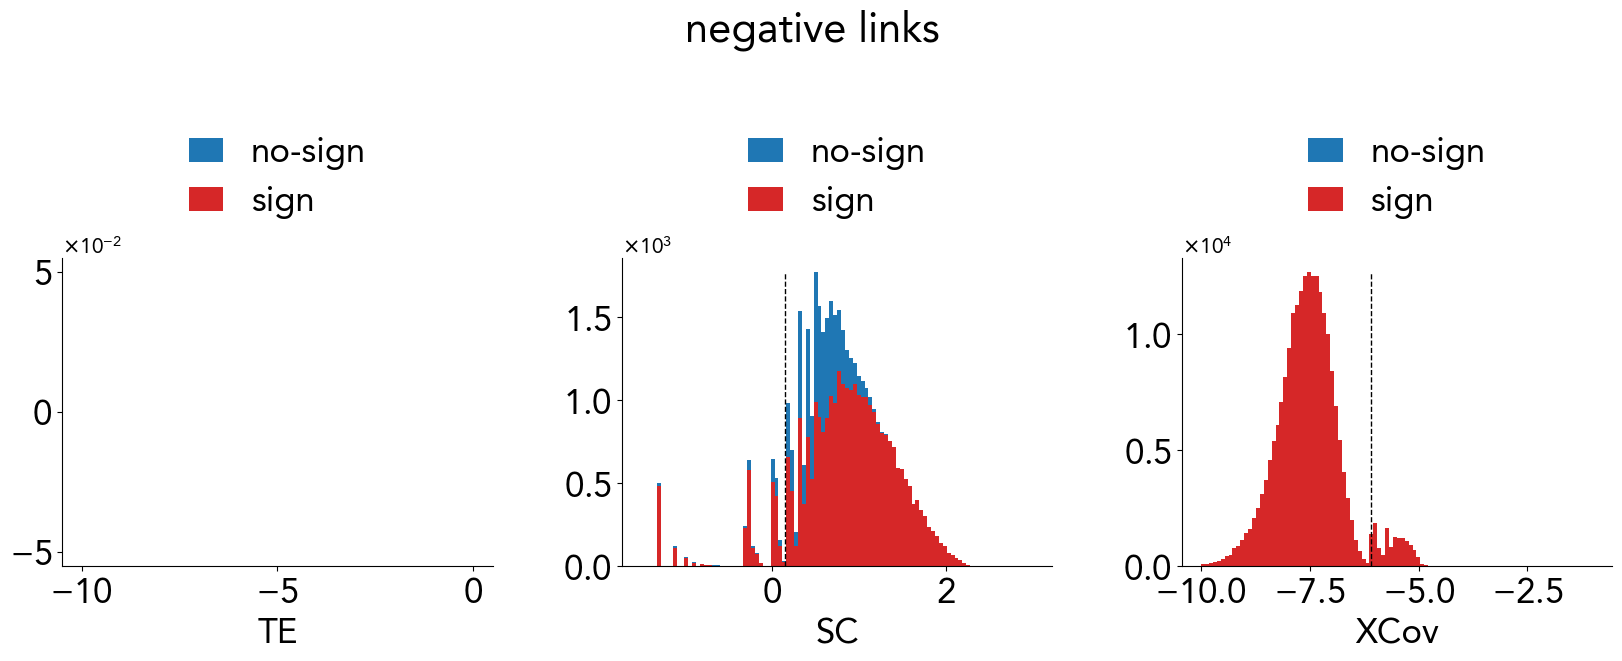

In [110]:
main_path=path_results+'Spontaneous_activity/'

_TE,  _TE_sign,  _zTE,  _zTE_sign, _TE_Pval   = lec.load_complete_measures(main_path, folder, folder_prefix='ECdata_',binsize=1, file_prefix='Cult_'+str(T_spont)+'min_', ECmeas = 'TE',  tp = 'pk', alpha=alpha_TE)
_SC,  _SC_sign,  _zSC,  _zSC_sign, _SC_Pval   = lec.load_complete_measures(main_path, folder, folder_prefix='ECdata_',binsize=1, file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'SC',  tp = 'pk', alpha=alpha_TE)
_XCov,  _XCov_sign,  _zXCov,  _zXCov_sign, _XCov_Pval   = lec.load_complete_measures(main_path, folder, folder_prefix='ECdata_',binsize=1, file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'XCov',  tp = 'pk', alpha=alpha_TE)

# limiting positive values
thresholdsP = [-6.1, 0.1, -6]; thr_noSig_P = [-6.1, 0.1, -6]

# limiting negative values
thresholdsN = [0, 0.15, -6.1]; thr_noSig_N = [0, 0.15, -6.1]


mats  = [_TE, _SC, _XCov]
mats2 = [_TE_sign, _SC_sign, _XCov_sign]
rangesP = [[-10,-1],[-1.5,4],[-10,-1]]
rangesN = [[-10,-1],[-1.5,3],[-10,-1]]
plot_PN_links(mats, mats2, labs, rangesP, thresholdsP, rangesN, thresholdsN)


# positive
cond = (_TE<10**thr_noSig_P[0]); _TE[cond]=0; del cond; cond = (_TE_sign<10**thresholdsP[0]); _TE_sign[cond]=0;  del cond
cond = (_SC<10**thr_noSig_P[1]) & (_SC>0); _SC[cond]=0;  del cond; cond = (_SC_sign<10**thresholdsP[1]) & (_SC_sign>0); _SC_sign[cond]=0;  del cond
cond = (_XCov<10**thr_noSig_P[2]) & (_XCov>=0); _XCov[cond]=0;  del cond; cond = (_XCov_sign<10**thresholdsP[2]) & (_XCov_sign>=0); _XCov_sign[cond]=0;  del cond

# negative links
cond = (-_SC<10**thr_noSig_N[1]) & (_SC<0); _SC[cond]=0;  del cond
cond = (-_SC_sign<10**thresholdsN[1]) & (_SC_sign<0); _SC_sign[cond]=0; del cond
cond = (-_XCov<10**thr_noSig_N[2]) & (_XCov<0); _XCov[cond]=0;  del cond; cond = (-_XCov_sign<10**thresholdsN[2]) & (_XCov_sign<0); _XCov_sign[cond]=0; del cond

# (source x target) IC matrix has size: (nStimChannels, nChannels)
# To compare EC with IC - we restrict (source x target) EC matrices from (nChannels, nChannels) to (nStimChannels, nChannels)
sort_ids = np.arange(len(channel))

TE   = _TE[np.ix_(indices,sort_ids)];           TE_sign   = _TE_sign[np.ix_(indices,sort_ids)];           zTE   = _zTE[np.ix_(indices,sort_ids)];           zTE_sign   = _zTE_sign[np.ix_(indices,sort_ids)];           TE_Pval   = _TE_Pval[np.ix_(indices,sort_ids)];
SC   = np.abs(_SC[np.ix_(indices,sort_ids)]);   SC_sign   = np.abs(_SC_sign[np.ix_(indices,sort_ids)]);   zSC   = np.abs(_zSC[np.ix_(indices,sort_ids)]);   zSC_sign   = np.abs(_zSC_sign[np.ix_(indices,sort_ids)]);   SC_Pval   = _SC_Pval[np.ix_(indices,sort_ids)];
XCov = np.abs(_XCov[np.ix_(indices,sort_ids)]); XCov_sign = np.abs(_XCov_sign[np.ix_(indices,sort_ids)]); zXCov = np.abs(_zXCov[np.ix_(indices,sort_ids)]); zXCov_sign = np.abs(_zXCov_sign[np.ix_(indices,sort_ids)]); XCov_Pval = _XCov_Pval[np.ix_(indices,sort_ids)];

dist_mat = net['dist_matrix']
Dmat     = dist_mat[indices,:]

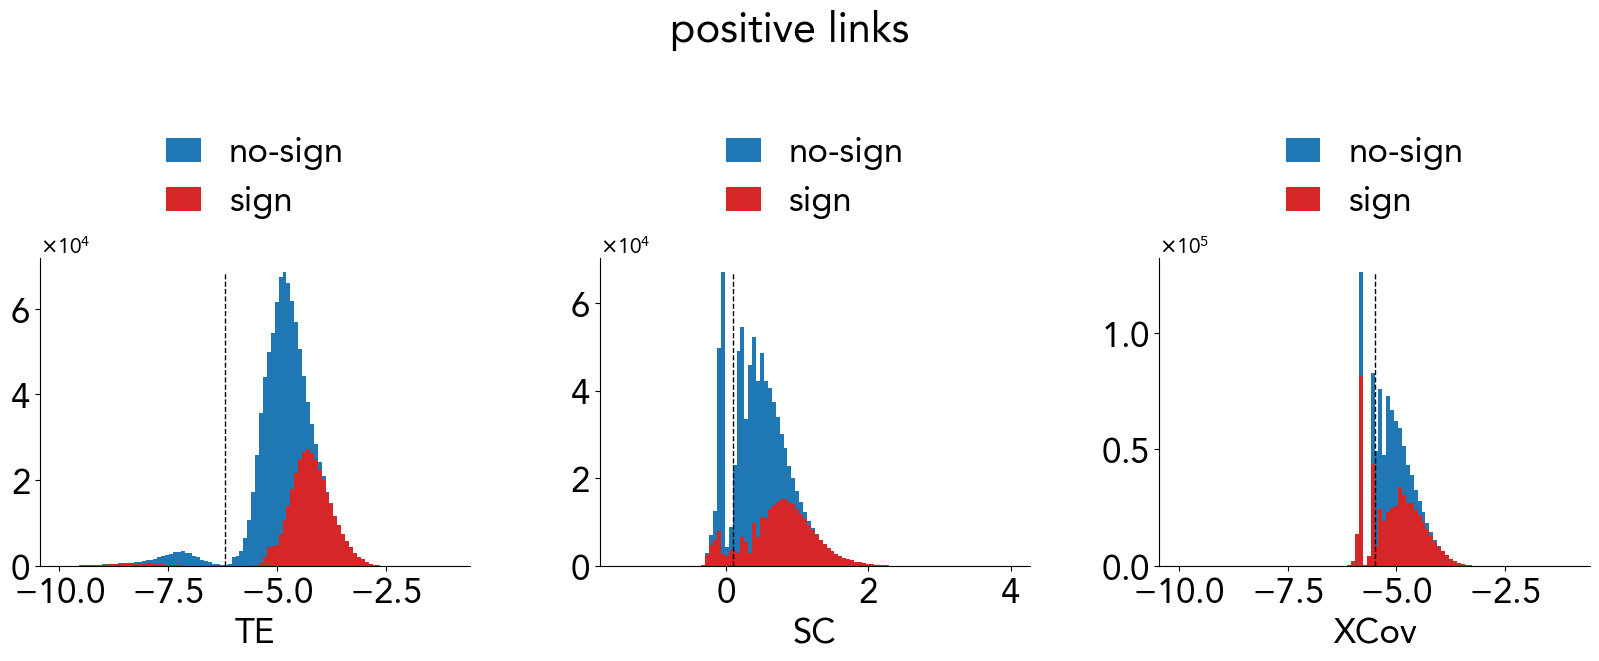

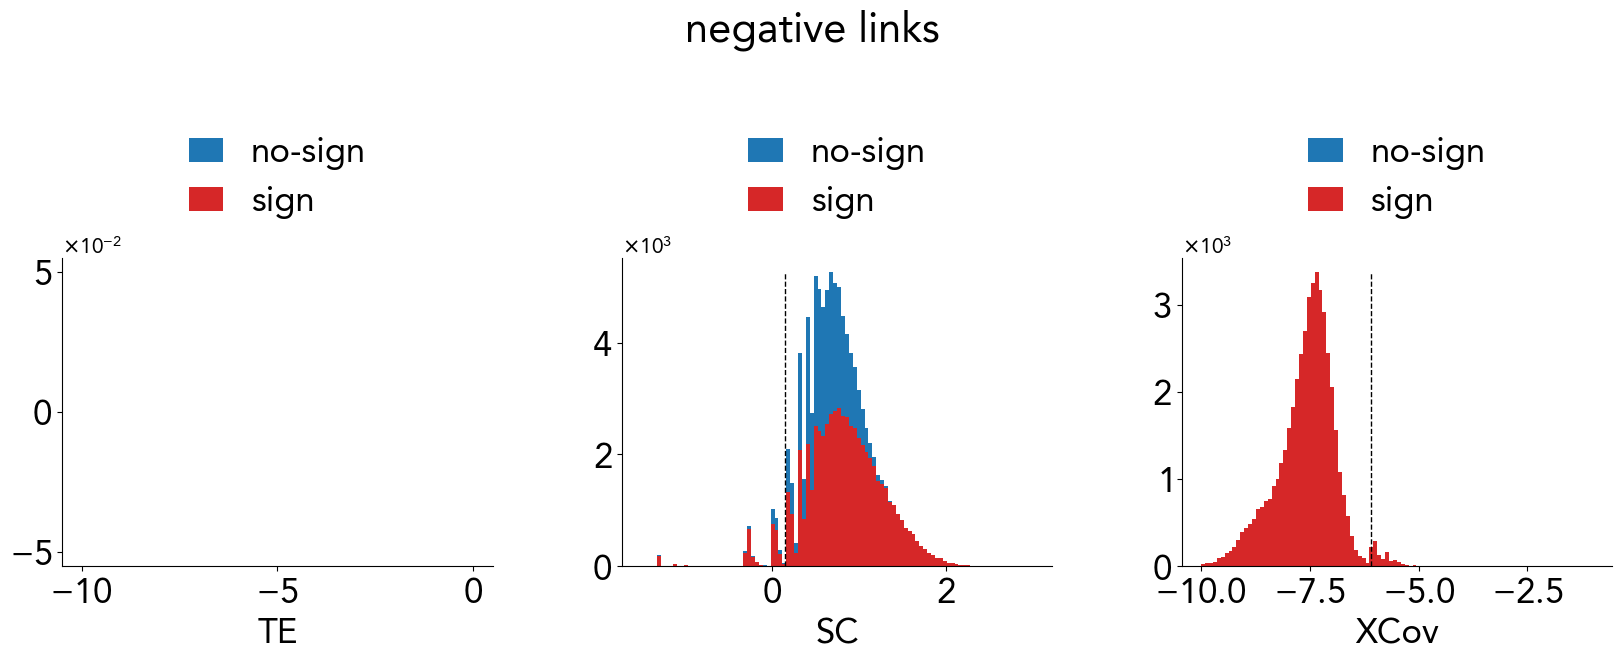

In [111]:
main_path=path_results+'Spontaneous_activity/'

_TE,  _TE_sign,  _zTE,  _zTE_sign, _TE_Pval   = lec.load_complete_measures(main_path, folder2, folder_prefix='ECdata_',binsize=1, file_prefix='Cult_'+str(T_spont)+'min_', ECmeas = 'TE',  tp = 'pk', alpha=alpha_TE)
_SC,  _SC_sign,  _zSC,  _zSC_sign, _SC_Pval   = lec.load_complete_measures(main_path, folder2, folder_prefix='ECdata_',binsize=1, file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'SC',  tp = 'pk', alpha=alpha_TE)
_XCov,  _XCov_sign,  _zXCov,  _zXCov_sign, _XCov_Pval   = lec.load_complete_measures(main_path, folder2, folder_prefix='ECdata_',binsize=1, file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'XCov',  tp = 'pk', alpha=alpha_TE)

# limiting positive values
thresholdsP = [-6.2, 0.1, -5.5]; thr_noSig_P = [-6.2, 0.1, -5.5]

# limiting negative values
thresholdsN = [0, 0.15, -6.1]; thr_noSig_N = [0, 0.15, -6.1]

mats  = [_TE, _SC, _XCov]
mats2 = [_TE_sign, _SC_sign, _XCov_sign]
rangesP = [[-10,-1],[-1.5,4],[-10,-1]]
rangesN = [[-10,-1],[-1.5,3],[-10,-1]]
plot_PN_links(mats, mats2, labs, rangesP, thresholdsP, rangesN, thresholdsN)

# positive
cond = (_TE<10**thr_noSig_P[0]); _TE[cond]=0; del cond; cond = (_TE_sign<10**thresholdsP[0]); _TE_sign[cond]=0;  del cond
cond = (_SC<10**thr_noSig_P[1]) & (_SC>0); _SC[cond]=0;  del cond; cond = (_SC_sign<10**thresholdsP[1]) & (_SC_sign>0); _SC_sign[cond]=0;  del cond
cond = (_XCov<10**thr_noSig_P[2]) & (_XCov>=0); _XCov[cond]=0;  del cond; cond = (_XCov_sign<10**thresholdsP[2]) & (_XCov_sign>=0); _XCov_sign[cond]=0;  del cond

# negative links
cond = (-_SC<10**thr_noSig_N[1]) & (_SC<0); _SC[cond]=0;  del cond
cond = (-_SC_sign<10**thresholdsN[1]) & (_SC_sign<0); _SC_sign[cond]=0; del cond
cond = (-_XCov<10**thr_noSig_N[2]) & (_XCov<0); _XCov[cond]=0;  del cond; cond = (-_XCov_sign<10**thresholdsN[2]) & (_XCov_sign<0); _XCov_sign[cond]=0; del cond

# (source x target) IC matrix has size: (nStimChannels, nChannels)
# To compare EC with IC - we restrict (source x target) EC matrices from (nChannels, nChannels) to (nStimChannels, nChannels)
sort_ids = np.arange(len(channel2))

TE2   = _TE[np.ix_(indices2,sort_ids)];           TE_sign2   = _TE_sign[np.ix_(indices2,sort_ids)];           zTE2   = _zTE[np.ix_(indices2,sort_ids)];           zTE_sign2   = _zTE_sign[np.ix_(indices2,sort_ids)];           TE_Pval2   = _TE_Pval[np.ix_(indices2,sort_ids)];
SC2   = np.abs(_SC[np.ix_(indices2,sort_ids)]);   SC_sign2   = np.abs(_SC_sign[np.ix_(indices2,sort_ids)]);   zSC2   = np.abs(_zSC[np.ix_(indices2,sort_ids)]);   zSC_sign2   = np.abs(_zSC_sign[np.ix_(indices2,sort_ids)]);   SC_Pval2   = _SC_Pval[np.ix_(indices2,sort_ids)];
XCov2 = np.abs(_XCov[np.ix_(indices2,sort_ids)]); XCov_sign2 = np.abs(_XCov_sign[np.ix_(indices2,sort_ids)]); zXCov2 = np.abs(_zXCov[np.ix_(indices2,sort_ids)]); zXCov_sign2 = np.abs(_zXCov_sign[np.ix_(indices2,sort_ids)]); XCov_Pval2 = _XCov_Pval[np.ix_(indices2,sort_ids)];

dist_mat2 = net2['dist_matrix']
Dmat2     = dist_mat2[indices2,:]

## 1.3 interventional connectivity (IC)

In [113]:
sort_ids = np.arange(len(channel))

#------------------------------------------------------------------------------------------------------------#
# compute/load IC
IC_compute=False
if IC_compute:
    
    with open(evoked_data + 'def_spikes.pkl', 'rb') as file:
        def_spikes = pickle.load(file)
        
    ks, ks_sign, ks_pval_FDR, ks_pval  = IC.compute_KS(Ntrials, def_units, def_chans, def_spikes, net['channel'], 
                                                       stim_start, Delta_pre, stim_stop, Delta_post, Tmax, alpha_th=alpha_th, 
                                                       id_trial_start=0, n_jobs=N_JOBS, verbose=True)
    ic_save(path_IC_data, ks, ks_pval, ks_pval_FDR)
    
    ks_bin, ks_sign_bin, ks_pval_FDR_bin, ks_pval_bin  = IC.compute_KS_binned(Ntrials, def_units, def_chans, def_spikes, net['channel'], stim_start, Delta_pre, stim_stop, Delta_post, Tmax, Nbins=Nbins, alpha_th=alpha_th, id_trial_start=0, n_jobs=N_JOBS, verbose=True)
    ic_save(path_ICbin_data, ks_bin, ks_pval_bin, ks_pval_FDR_bin)
else:
    
    # load data
    ks, ks_pval, ks_pval_FDR = ic_load(path_IC_data)
    ks_sign     = np.copy(ks); ks_sign[ks_pval>alpha_th] = 0
    #ks_sign_FDR = np.copy(ks); ks_sign[ks_pval_FDR>alpha_th] = 0

    ks_bin, ks_pval_bin, ks_pval_FDR_bin = ic_load(path_IC_data)
    ks_sign_bin     = np.copy(ks_bin); ks_sign_bin[ks_pval_bin>alpha_th] = 0; ks_sign_bin[np.isnan(ks_bin)]=0
    #ks_sign_FDR_bin = np.copy(ks_bin); ks_sign_bin[ks_pval_FDR_bin>alpha_th] = 0; ks_sign_bin[np.isnan(ks_bin)]=0

ks      = ks[:,sort_ids]
ks_sign = ks_sign[:,sort_ids]
ks_pval = ks_pval[:,sort_ids]
    
ks_bin      = ks_bin[:,sort_ids]
ks_sign_bin = ks_sign_bin[:,sort_ids]
ks_pval_bin = ks_pval_bin[:,sort_ids]
#------------------------------------------------------------------------------------------------------------#


In [114]:
sort_ids = np.arange(len(channel2))

#------------------------------------------------------------------------------------------------------------#
# compute/load IC
IC_compute=False
if IC_compute:
    with open(evoked_data2 + 'def_spikes.pkl', 'rb') as file:
        def_spikes2 = pickle.load(file)
        
    ks2, ks_sign2, ks_pval_FDR2, ks_pval2  = IC.compute_KS(Ntrials, def_units2, def_chans2, def_spikes2, net2['channel'], 
                                                       stim_start, Delta_pre, stim_stop, Delta_post, Tmax, alpha_th=alpha_th, 
                                                       id_trial_start=0, n_jobs=N_JOBS, verbose=True)
    ic_save(path_IC_data2, ks2, ks_pval2, ks_pval_FDR2)
    
    ks_bin2, ks_sign_bin2, ks_pval_FDR_bin2, ks_pval_bin2  = IC.compute_KS_binned(Ntrials, def_units2, def_chans2, def_spikes2, net2['channel'], stim_start, Delta_pre, stim_stop, Delta_post, Tmax, Nbins=Nbins, alpha_th=alpha_th, id_trial_start=0, n_jobs=N_JOBS, verbose=True)
    ic_save(path_ICbin_data2, ks_bin2, ks_pval_bin2, ks_pval_FDR_bin2)
else:
    
    # load data
    ks2, ks_pval2, ks_pval_FDR2 = ic_load(path_IC_data2)
    ks_sign2     = np.copy(ks2); ks_sign2[ks_pval2>alpha_th] = 0
    #ks_sign_FDR = np.copy(ks); ks_sign[ks_pval_FDR>alpha_th] = 0

    # load data
    ks_bin2, ks_pval_bin2, ks_pval_FDR_bin2 = ic_load(path_IC_data2)
    ks_sign_bin2     = np.copy(ks_bin2); ks_sign_bin2[ks_pval_bin2>alpha_th] = 0; ks_sign_bin2[np.isnan(ks_bin2)]=0
            
ks2      = ks2[:,sort_ids]
ks_sign2 = ks_sign2[:,sort_ids]
ks_pval2 = ks_pval2[:,sort_ids]

ks_bin2      = ks_bin2[:,sort_ids]
ks_sign_bin2 = ks_sign_bin2[:,sort_ids]
ks_pval_bin2 = ks_pval_bin2[:,sort_ids]
#------------------------------------------------------------------------------------------------------------#


# 2. Channel responses

## 2.1 Channels maps

### 2.0.1 response map

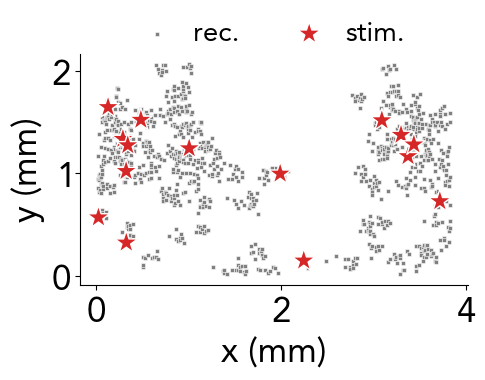

In [88]:
# most responsive channels
in_sign_bin = np.sum(ks_sign_bin,axis=0)

array_cols = ['tab:red' for i in range(len(indices))]
plot_map_rec(pos, 'grey', channel, def_chans, indices, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=2, y_leg=1.25, cmap = None,
                   outf=path_imgs+'1.1channel_map_network1.pdf', show_plot=show_plot)


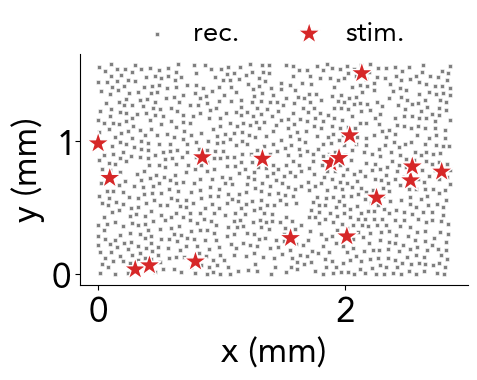

In [89]:
# most responsive channels

array_cols = ['tab:red' for i in range(len(indices2))]
plot_map_rec(pos2, 'grey', channel2, def_chans2, indices2, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=2, y_leg=1.25, cmap = None,
                   outf=path_imgs+'1.1channel_map_network2.pdf', show_plot=show_plot)


### Ground truth

In [87]:
def plot_map_rec_4(pos_, W, col_list, channel, def_chans, indices, array_col, cmap=None, cbar_label='', title=None, dotcolor='lightgrey',
                 dotsize=4.5, starsize = 1350, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2, 
                 figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    
    pos = pos_[:,:]/1000

    x = np.copy(pos[:,0])
    y = np.copy(pos[:,1])
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    scatter_rec = ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', c=col_list, edgecolor='white',
                             label='rec. channels', cmap=cmap, zorder=0)
    if cmap is not None:
        cbar        = fig.colorbar(scatter_rec, ax=ax, label=cbar_label)
    
    # stimulation channels
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], c=array_col, edgecolor='white', s=starsize, marker='*', alpha=1, zorder=1,
                         label='stim. channels')

    W_pos = np.where(W > 0.0, W, 0.0)   # "excitatory" by sign
    W_neg = np.where(W < 0.0, W, 0.0)   # "inhibitory" by sign
    rows, cols = np.nonzero(W_pos)
    for i, j in zip(rows, cols):
        ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.8, lw=.03, zorder=0)
    rows, cols = np.nonzero(W_neg)
    for i, j in zip(rows, cols):
        ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.8, lw=.03, zorder=0)
        
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM-5, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    if title:
        ax.set_title(title)

    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


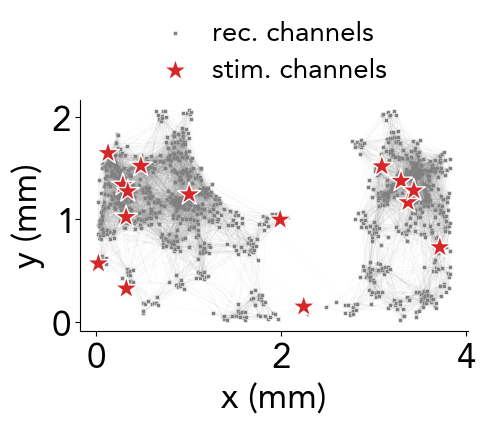

In [90]:
array_cols = ['tab:red' for i in range(len(indices))]
plot_map_rec_4(pos, net['W_effective'], 'grey', channel, def_chans, indices, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.45, cmap = None,
                   outf=path_imgs+'1.2_channels_responsive_network1.pdf', show_plot=show_plot)


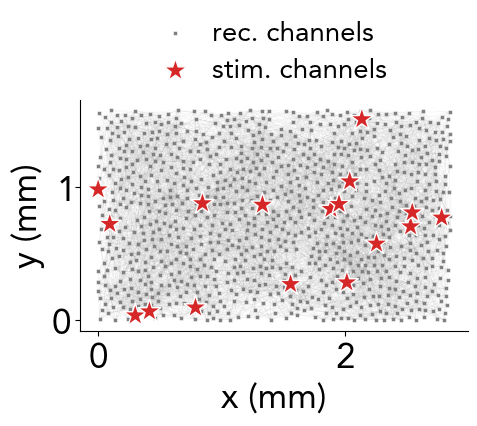

In [92]:
array_cols = ['tab:red' for i in range(len(indices2))]
plot_map_rec_4(pos2, net2['W_effective'], 'grey', channel2, def_chans2, indices2, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.45, cmap = None,
                   outf=path_imgs+'1.2_channels_responsive_network2.pdf', show_plot=show_plot)


### 2.1.2 channel map – rec channels highlighted 

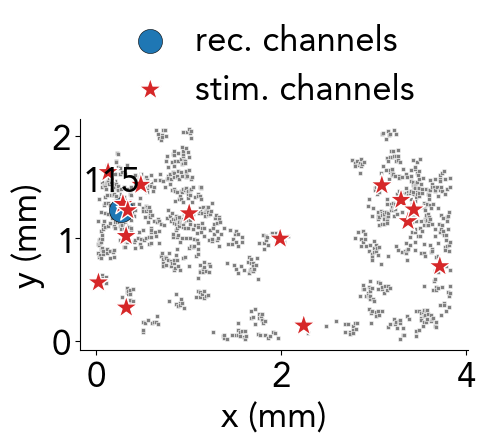

In [96]:
array_cols = ['tab:red' for i in range(len(indices))]
plot_channel_map_3(pos, [115], [100], channel, def_chans, indices, array_cols, rec_color='tab:blue', figsize=(5, 3), dotcolor='gray',
                   dotsize=20, starsize = 300, starsize_center = None, text_dim = 25, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.55,
                   rec_text=True, cmap=None,ax=None,  outf=path_imgs+'1.2_III_channels_map_network1.pdf', show_plot=show_plot)

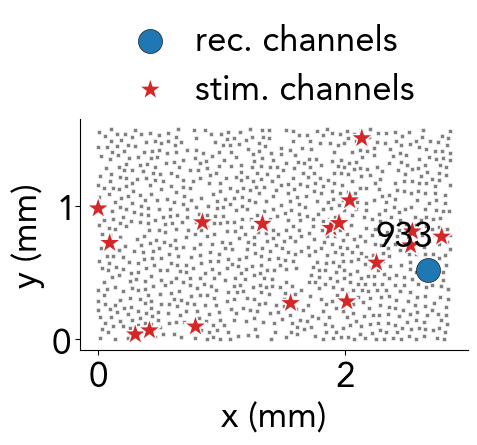

In [97]:
array_cols = ['tab:red' for i in range(len(indices2))]
plot_channel_map_3(pos2, [933], [933], channel2, def_chans2, indices2, array_cols, rec_color='tab:blue', figsize=(5, 3), dotcolor='gray',
                   dotsize=20, starsize = 300, starsize_center = None, text_dim = 25, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.55,
                   rec_text=True, cmap=None,ax=None,  outf=path_imgs+'1.2_III_channels_map_network2.pdf', show_plot=show_plot)


## 2.2 100 rec. channels with highest in-strength – plot IC/TE as function of distance from stim.channel

In [101]:
def plot_scatter(ic_mat, ec_mat, zeroExp=-11, log=False, Wmat=None, xlabel='IC', ylabel='EC', title=None, dotsize=0.1, 
                 cmap=None, edgecolor=None, linewidths=0.2, regcolor='tab:red', dotcolor='tab:blue', reg_line=False, show_corr=True,
                 xmin=None, xmax=None, ymin=None, ymax=None, ax=None, alpha=1, figsize=(3.5,3), outf=None, show_plot=False):
    import seaborn as sns
    from scipy.stats import pearsonr, spearmanr, gaussian_kde
    ic_vec = ic_mat.flatten()
    if log:
        ec_vec = np.log10(ec_mat.flatten()+10**zeroExp)
        x=ic_vec[ec_mat.flatten()!=0]
        y=ec_vec[ec_mat.flatten()!=0]
        if Wmat is not None:
            w=Wmat[ec_mat.flatten()!=0]
    else:
        ec_vec = ec_mat.flatten()
        x=ic_vec
        y=ec_vec
        if Wmat is not None:
            w=Wmat.flatten()

    if ymin is not None and ymax is not None:
        y_ = np.copy(y)        
        x = x[(y_>=ymin) & (y_<ymax)]
        y = y_[(y_>=ymin) & (y_<ymax)]
        if Wmat is not None:
            w=Wmat.flatten()
            w = w[(y_>=ymin) & (y_<ymax)]
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
        
    if cmap:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        vmax = np.max(z); vmin = vmax; 
        # Plot with density-based color
        scatter = ax.scatter(x, y, c=z, s=dotsize, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label(r'density', fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)
    else:
        ax.scatter(x, y, s=dotsize, c=dotcolor, edgecolor=edgecolor, linewidths=linewidths, alpha=alpha)
        
    if Wmat is not None:
        scatter = ax.scatter(x[w!=0], y[w!=0], c='none', s=dotsize, edgecolor='tab:red', linewidths=1, alpha=1)
        
    if reg_line:
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
    
    if show_corr:
        cp = np.round(pearsonr(ic_vec,ec_vec)[0],2)
        cs = np.round(spearmanr(ic_vec,ec_vec)[0],2)
        pval_p = pearsonr(ic_vec,ec_vec)[1]
        pval_s = spearmanr(ic_vec,ec_vec)[1]
        if title:
            ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
    else:
        if title:
            ax.set_title(title)
        
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin,ymax)
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin,xmax)
        
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel);

    if cmap:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, pwr_cbar_min=-2, pwr_cbar_max=2,  DIM = DIM)
    else:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = None, DIM = DIM)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


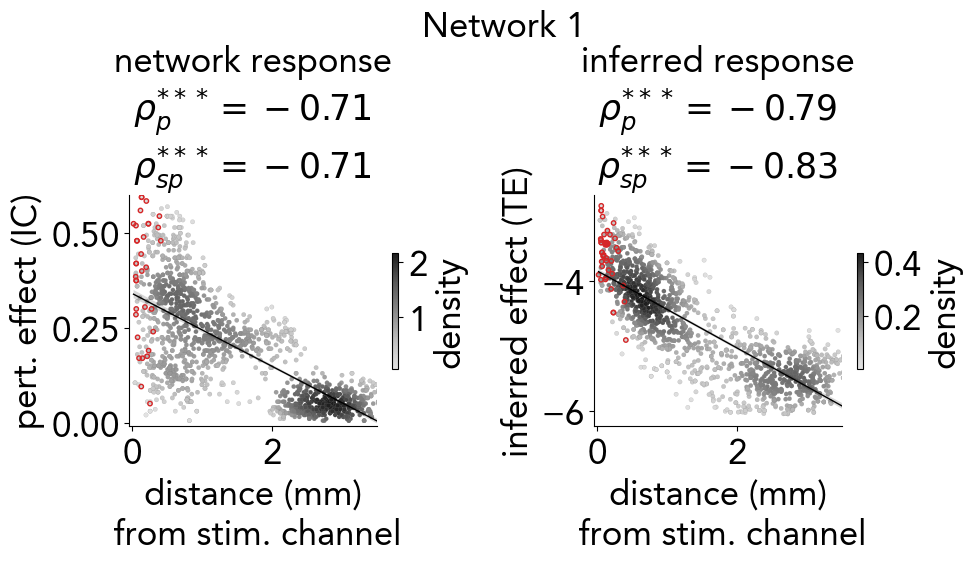

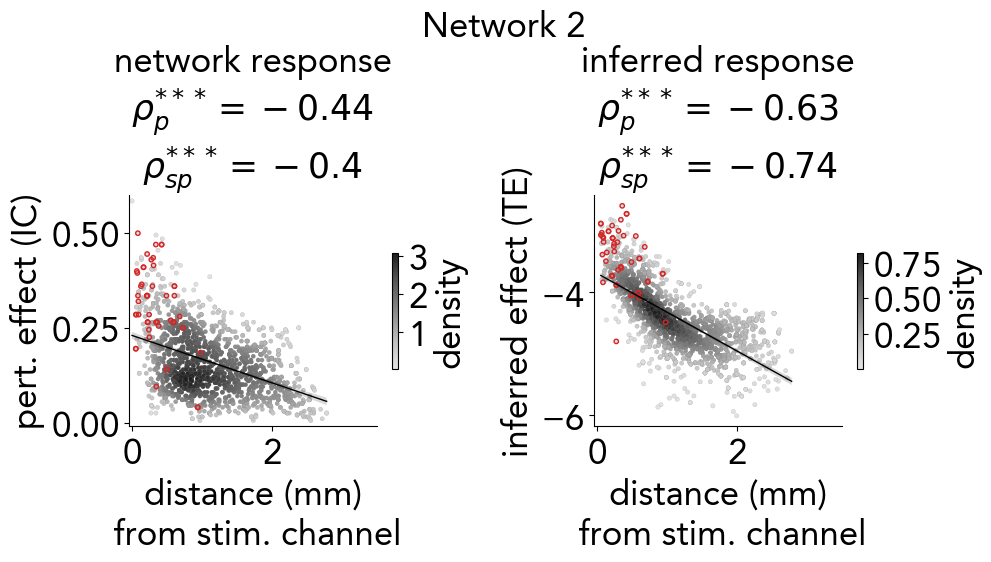

In [121]:
in_sign_bin = np.sum(ks,axis=0)
L           = np.argsort(in_sign_bin)[::-1]
cmap=truncate_cmap(plt.get_cmap('Greys'), minval=0.2, maxval=0.9)
w_eff = net['W_effective']

for w_eff,IC_mat, TE_mat, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans, _indices in zip([net['W_effective'],net2['W_effective']],[ks,ks2], [TE,TE2], ['network1','network2'], ['Network 1','Network 2'], [channel,channel2], [pos/1000,pos2/1000], [def_units,def_units2], [def_chans,def_chans2], [indices,indices2] ):
    
    in_sign_bin = np.sum(IC_mat,axis=0)
    L           = np.argsort(in_sign_bin)[::-1]
    
    fig,axs = plt.subplots(1,2,figsize=(10,3))
    for y, lab, log, ax in zip([IC_mat, TE_mat], ['IC','TE'], [False,True], axs):
    
        dists   = []
        y_vals = []
        Wmat = []
        for i in range(100):
            i_rec   = int(np.where(in_sign_bin==in_sign_bin[L[i]])[0][0])
            sorted_units, sorted_d = sort_units_with_distance(i_rec, _channel, _pos, _def_units, _def_chans)
            dists   = np.concatenate([dists, sorted_d])
            y_vals = np.concatenate([y_vals, y[sorted_units,i_rec]])
            Wmat    = np.concatenate([Wmat, w_eff[_indices[sorted_units],i_rec]])
        
        dotsize = 10
         
        # lab+'\n'+f'rec. chan. {i_rec}'    
        ylabel  = 'pert. effect (IC)'
        xlabel  = 'distance (mm)\n from stim. channel'
        if log==False:
            title   = 'network response'
            ylabel  = 'pert. effect (IC)'
            plot_scatter(dists, y_vals, -8, Wmat=Wmat, xlabel=xlabel, ylabel=ylabel, dotsize=dotsize, edgecolor='grey', linewidths=0.1, 
                         dotcolor='k', figsize=(4,3), xmin=-0.05, xmax=3.5, ymin=-0.01, ymax=0.6,
                         log=log,reg_line=True,  ax = ax, regcolor='k', cmap=cmap, title=title, outf=path_imgs + f'2.0.3.1_IC_vs_rec_distances_{lab}.pdf',  show_plot=True) 
        else:
            title   = 'inferred response'
            ylabel  = 'inferred effect (TE)'
            plot_scatter(dists, y_vals, -8, Wmat=Wmat, xlabel=xlabel, ylabel=ylabel, dotsize=dotsize, edgecolor='grey', linewidths=0.1, 
                         dotcolor='k', figsize=(4,3), xmin=-0.05, xmax=3.5, #ymin=-0.01, ymax=0.8,
                         log=log,reg_line=True,  ax = ax, regcolor='k', cmap=cmap, title=title, outf=path_imgs + f'2.0.3.1_IC_vs_rec_distances_{lab}.pdf',  show_plot=True) 
    
    fig.subplots_adjust(wspace=0.5)
    fig.suptitle(cult_lab,y=1.5,fontsize=DIM)
    plt.savefig(path_imgs+f'2.1_edge_vs_rec_distances_{cult_save}.pdf', bbox_inches='tight')


## 2.2 focus: 1 rec. channel - channel response vs. stim channel distances

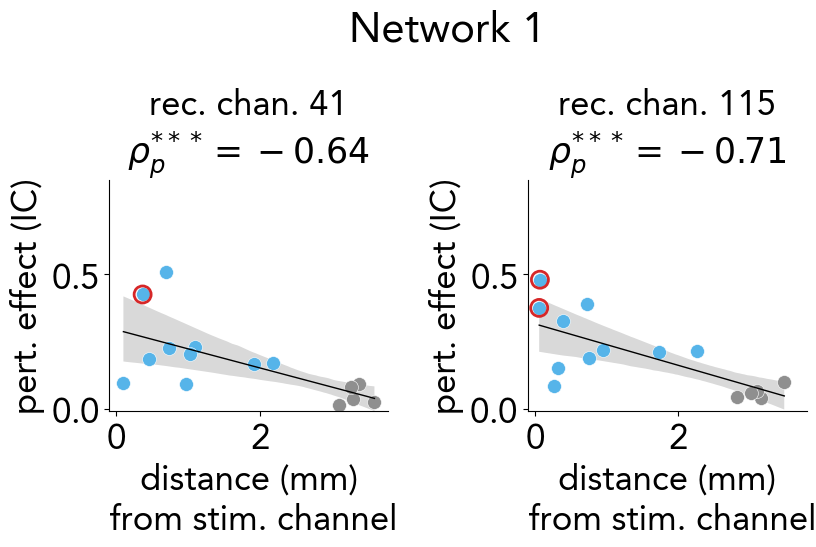

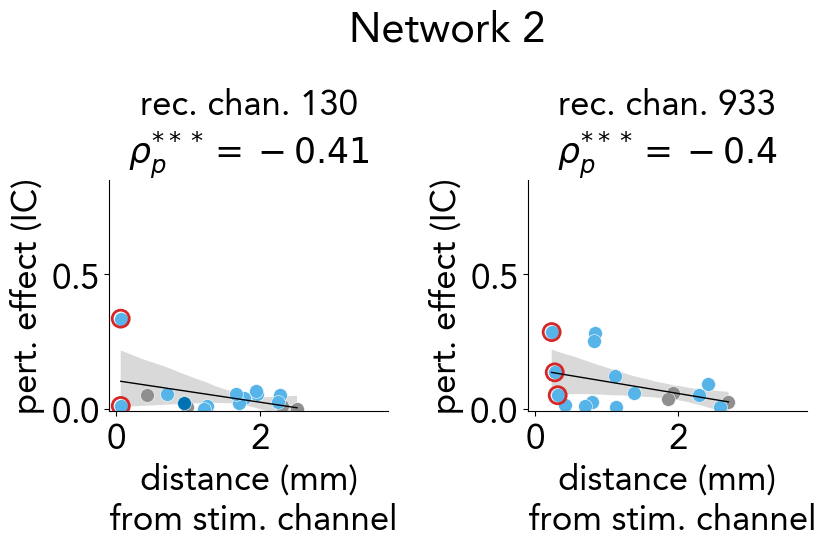

In [119]:
col_d = '#0072B2'
col_u = '#56B4E9'
col_n = '#8F8F8F'

dotsize = 100; KS = ks
col_41 = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_n, col_n, col_n,][::-1]
col_115 = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_n, col_n, col_n,][::-1]

col_130 = [col_u, col_u, col_n, col_u, col_d, col_n, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n][::-1]
col_933 = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_u, col_u, col_u, col_n][::-1]

show_corr = True
reg_line  = False
regcolor  = 'k'
reg_line=True

import seaborn as sns
for w_eff,KS, rec_chans, rec_cols, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans, _indices in zip([net['W_effective'],net2['W_effective']],
                                                                                                          [ks,ks2],[[41,115],[130, 933]], 
                                                                                                [[col_41,col_115],[col_130,col_933]],
                                                                                                ['network1','network2'], 
                                                                                                ['Network 1','Network 2'], 
                                                                                                [channel,channel2], [pos,pos2], 
                                                                                                [def_units,def_units2], 
                                                                                                [def_chans,def_chans2],
                                                                                                [indices, indices2]):

    fig,axs = plt.subplots(1,2,figsize=(9,3))
    for i_rec, col_post,ax in zip(rec_chans, rec_cols, axs):
        sorted_units, sorted_d = sort_units_with_distance(i_rec, _channel, _pos/1000, _def_units, _def_chans)
        
        title  = f'rec. chan. {i_rec}'
        ylabel = 'pert. effect (IC)'
        xlabel = 'distance (mm)\n from stim. channel'
    
        x = sorted_d
        y = KS[sorted_units,i_rec]
        
        if reg_line:
            sns.regplot(x=x, y=y, ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
        for i in range(len(sorted_d)):
            ax.scatter(x[i], y[i], s = dotsize, c=col_post[i], edgecolor='white', linewidths=0.4)
        for i in range(len(sorted_d)):
            if w_eff[_indices[sorted_units[i]],i_rec]!=0:
                ax.scatter(x[i], y[i], s = dotsize+50, c='none', edgecolor='tab:red', linewidths=2)
        if show_corr:
            cp = np.round(pearsonr(x,y)[0],2)
            cs = np.round(spearmanr(x,y)[0],2)
            pval_p = pearsonr(x,y)[1]
            pval_s = spearmanr(x,y)[1]
            if title:
                ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$')#+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
            else:
                ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$')#+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            if title:
                ax.set_title(title)
        ax.set_ylim(-0.01,0.85)
        ax.set_xlim(-0.1,3.8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        pl.set_format(ax=ax, DIM=DIM, pwr_x_min=-2, pwr_y_min=-2)
    fig.subplots_adjust(wspace=0.5)
    fig.suptitle(cult_lab,y=1.45)
    
    if reg_line:
        fig.savefig(path_imgs + f'2.2_IC_vs_rec{i_rec}_distance_regline_{cult_save}.pdf', bbox_inches='tight')
    else:
        fig.savefig(path_imgs + f'2.2_IC_vs_rec{i_rec}_distance_{cult_save}.pdf', bbox_inches='tight')


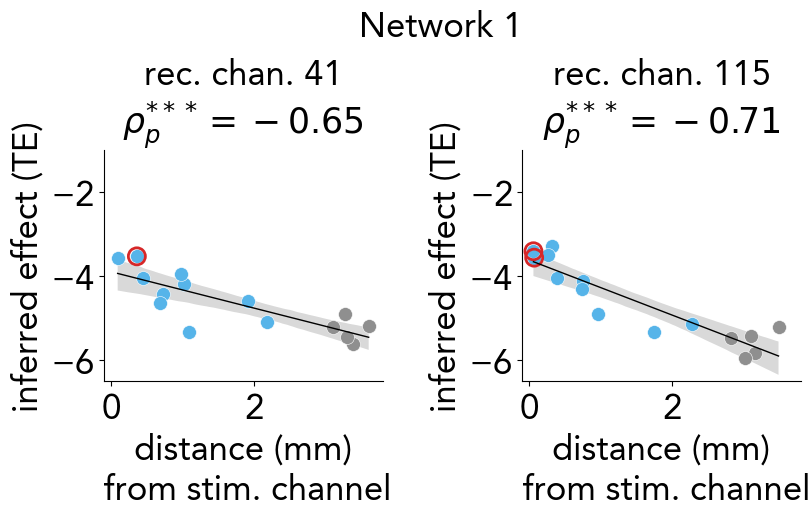

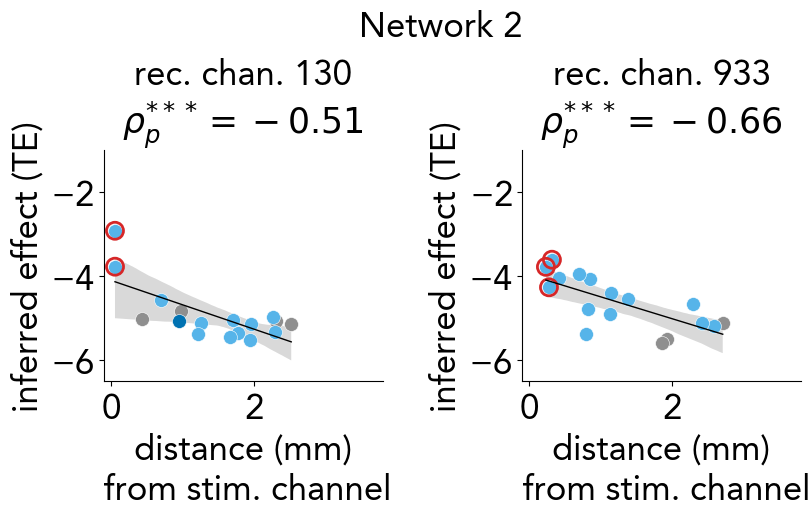

In [127]:
col_d = '#0072B2'
col_u = '#56B4E9'
col_n = '#8F8F8F'

dotsize = 100; KS = ks
col_41 = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_n, col_n, col_n,][::-1]
col_115 = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_n, col_n, col_n,][::-1]

col_130 = [col_u, col_u, col_n, col_u, col_d, col_n, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n][::-1]
col_933 = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_u, col_u, col_u, col_n][::-1]

show_corr = True
reg_line  = False
regcolor  = 'k'
reg_line=True

import seaborn as sns
for w_eff,KS, rec_chans, rec_cols, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans, _indices in zip([net['W_effective'],net2['W_effective']],
                                                                                                          [TE,TE2],[[41,115],[130, 933]], 
                                                                                                [[col_41,col_115],[col_130,col_933]],
                                                                                                ['network1','network2'], 
                                                                                                ['Network 1','Network 2'], 
                                                                                                [channel,channel2], [pos,pos2], 
                                                                                                [def_units,def_units2], 
                                                                                                [def_chans,def_chans2],
                                                                                                [indices, indices2]):

    fig,axs = plt.subplots(1,2,figsize=(9,3))
    for i_rec, col_post,ax in zip(rec_chans, rec_cols, axs):
        sorted_units, sorted_d = sort_units_with_distance(i_rec, _channel, _pos/1000, _def_units, _def_chans)
        
        title  = f'rec. chan. {i_rec}'
        ylabel = 'inferred effect (TE)'
        xlabel = 'distance (mm)\n from stim. channel'
    
        x = sorted_d
        y = KS[sorted_units,i_rec]
        
        
        if reg_line:
            sns.regplot(x=x, y=np.log10(y+10**-7), ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
        for i in range(len(sorted_d)):
            ax.scatter(x[i], np.log10(y+10**-7)[i], s = dotsize, c=col_post[i], edgecolor='white', linewidths=0.4)
        
        for i in range(len(sorted_d)):
            if w_eff[_indices[sorted_units[i]],i_rec]!=0:
                ax.scatter(x[i], np.log10(y+10**-7)[i], s = dotsize+50, c='none', edgecolor='tab:red', linewidths=2)
        if show_corr:
            cp = np.round(pearsonr(x,y)[0],2)
            cs = np.round(spearmanr(x,y)[0],2)
            pval_p = pearsonr(x,y)[1]
            pval_s = spearmanr(x,y)[1]
            if title:
                ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$')#+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
            else:
                ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$')#+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            if title:
                ax.set_title(title)
        ax.set_ylim(-6.5,-1)
        ax.set_xlim(-0.1,3.8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        pl.set_format(ax=ax, DIM=DIM, pwr_x_min=-2, pwr_y_min=-2)
    fig.subplots_adjust(wspace=0.5)
    fig.suptitle(cult_lab,y=1.35, fontsize=DIM)
    
    if reg_line:
        fig.savefig(path_imgs + f'2.3_TE_vs_rec{i_rec}_distance_regline_{cult_save}.pdf', bbox_inches='tight')
    else:
        fig.savefig(path_imgs + f'2.3_TE_vs_rec{i_rec}_distance_{cult_save}.pdf', bbox_inches='tight')


# 3. Spike counts responses

## 3.1 store the spike counts for each stim unit and for each trial

In [148]:
# store the spike counts for each stim unit and for each trial
# counts_dict: pre + stim + post  blocks are consecutive 
DeltaT_sec=2
counts_dict = {}
for bin_sz in [0.002,0.005,0.01]:
    # compute spike counts
    s_counts = compute_spike_counts(spikes, binsize=bin_sz)
    counts_dict[bin_sz] = {}
    
    trial_block = len(def_units)*DeltaT_sec
    for i_unit in range(len(def_units)):
        counts_dict[bin_sz][i_unit] = {}
        for n in range(Ntrials):
            tbin_min = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz)
            tbin_max = int(int(trial_block) * n + int(DeltaT_sec) * (i_unit) ) * int(1/bin_sz) + int(1.8/bin_sz)
            counts_dict[bin_sz][i_unit][n] = (s_counts[tbin_min:tbin_max,:])


In [147]:
# store the spike counts for each stim unit and for each trial
# counts_dict: pre + stim + post  blocks are consecutive 
DeltaT_sec=2
counts_dict2 = {}
for bin_sz in [0.002,0.005, 0.01]:
    # compute spike counts
    s_counts = compute_spike_counts(spikes2, binsize=bin_sz)
    counts_dict2[bin_sz] = {}
    
    trial_block = len(def_units2)*DeltaT_sec
    for i_unit in range(len(def_units2)):
        counts_dict2[bin_sz][i_unit] = {}
        for n in range(Ntrials):
            tbin_min = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz)
            tbin_max = int(int(trial_block) * n + int(DeltaT_sec) * (i_unit) ) * int(1/bin_sz) + int(1.8/bin_sz)
            counts_dict2[bin_sz][i_unit][n] = (s_counts[tbin_min:tbin_max,:])


## 3.2 Choose a recording channel. For each stimulation channel store all trials, with stim progression sorted by distance

### 3.2.1 plot (stim-rec) SPIKE COUNTS trials

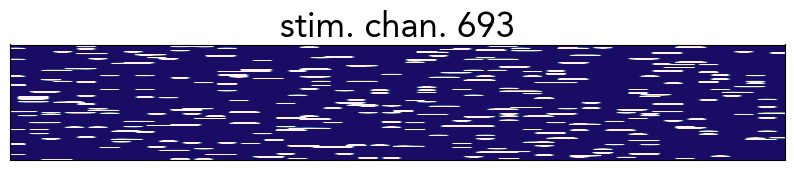

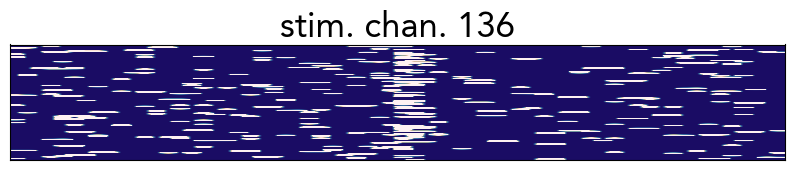

In [135]:
# NETWORK 1
bin_sz = 0.01
for i_rec in [115]:
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    for i_unit in (sorted_units):
        if np.isin(indices[i_unit], np.array([136, 693, 836])):
            fig,ax = plt.subplots(1,1,figsize=(10,1.5))
            trials = (counts_dict[bin_sz][i_unit][0])[int(0.7/bin_sz):int(1.36/bin_sz),i_rec]
            for n in range(1,Ntrials):
                trials = np.vstack([ trials, (counts_dict[bin_sz][i_unit][n])[int(0.7/bin_sz):int(1.36/bin_sz),i_rec]])
            ax.imshow(trials,aspect='auto', cmap=Cmap('lapaz'),vmin=0, vmax=0.1,)
            fig.subplots_adjust(hspace=0.4)
            ax.set_title(f'stim. chan. {indices[i_unit]}')
            ax.set_xticks([])
            ax.set_yticks([])
            plt.savefig(path_imgs + f'3.1_spike_counts{i_rec}_stim{indices[i_unit]}_culture1.pdf', bbox_inches='tight')
            

#### 2.2.2.2 Choose a recording channel. Plot SPIKE COUNTS trials, for all stim channels sorted by distance

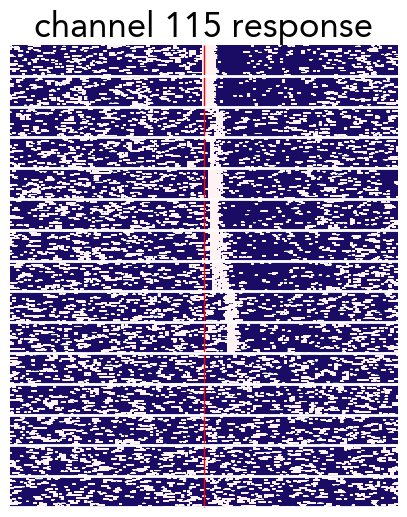

In [136]:
bin_sz = 0.005
for i_rec in [115]: #[354,100,618,795,339, 19,41,115,200,799]:
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    plot_counts(i_rec, sorted_units, indices, counts_dict[bin_sz], bin_sz=bin_sz, figsize=(5,6), outf=path_imgs+f'3.2_s_counts_recChan_{i_rec}.pdf', show_plot=show_plot)
    

# 4. Average responses

## 4.1 PLOT TRACES (all trial)

Choose a recording channel. For each stim channel, do the mean of the trial spike counts. Sort the plot order by rec-stim distance

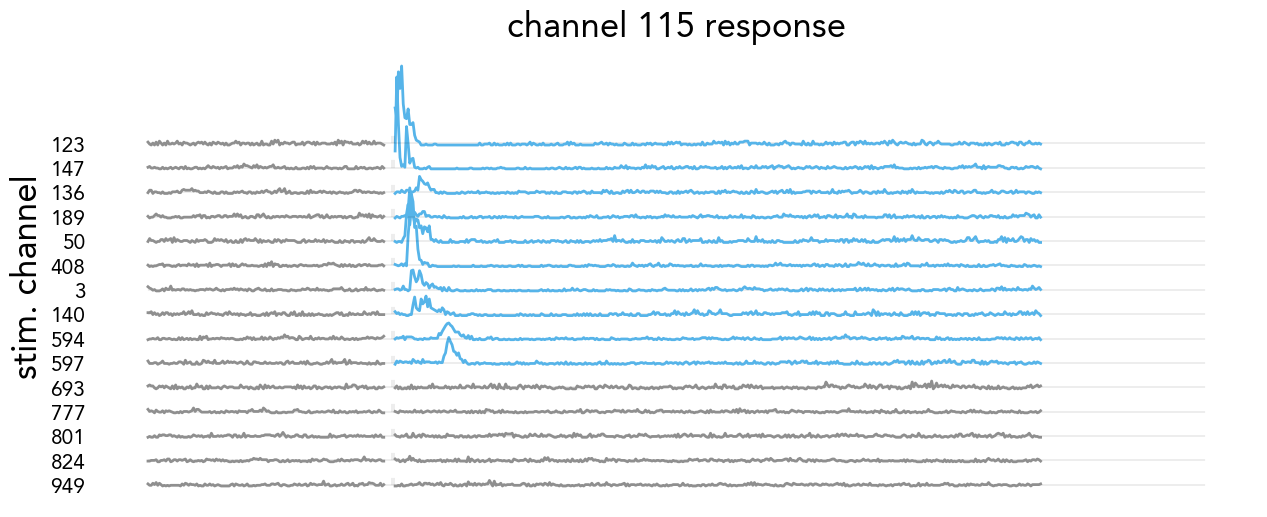

In [168]:
col_d = '#0072B2'
col_u = '#56B4E9'
col_n = '#8F8F8F'
bin_sz = 0.002
i=0
i_rec = 115
col_post = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_n, col_n, col_n,][::-1]
sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
plot_traces(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post, col_n, bin_sz=bin_sz, n_ampli=1,#5/(i+1), 
            pre_start=0.7, pre_stop=0.99, post_start=1.004, post_stop=2, stim0=1., stimEnd=1.+0.003,
            figsize=(15,6), outf=path_imgs+f'2.3.1_tracesAlltrial_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms.pdf', show_plot=show_plot)


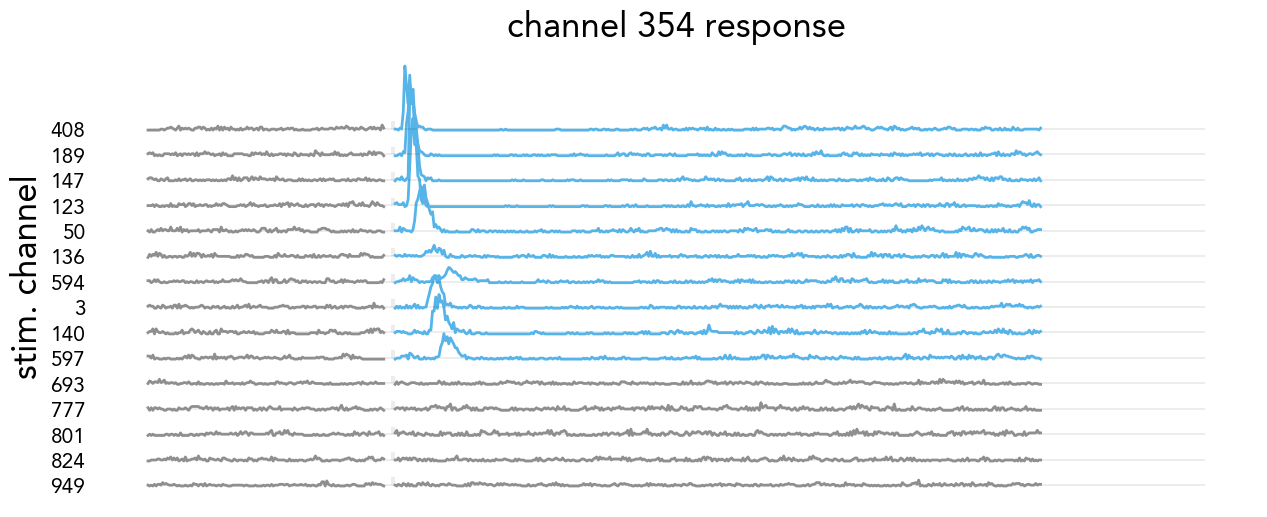

In [169]:
col_d = '#0072B2'
col_u = '#56B4E9'
col_n = '#8F8F8F'
bin_sz = 0.002
i=0
i_rec = 354
col_post = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_n, col_n, col_n,][::-1]
sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
plot_traces(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post, col_n, bin_sz=bin_sz, n_ampli=1,#5/(i+1), 
            pre_start=0.7, pre_stop=0.99, post_start=1.004, post_stop=2, stim0=1., stimEnd=1.+0.003,
            figsize=(15,6), outf=path_imgs+f'2.3.1_tracesAlltrial_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms.pdf', show_plot=show_plot)


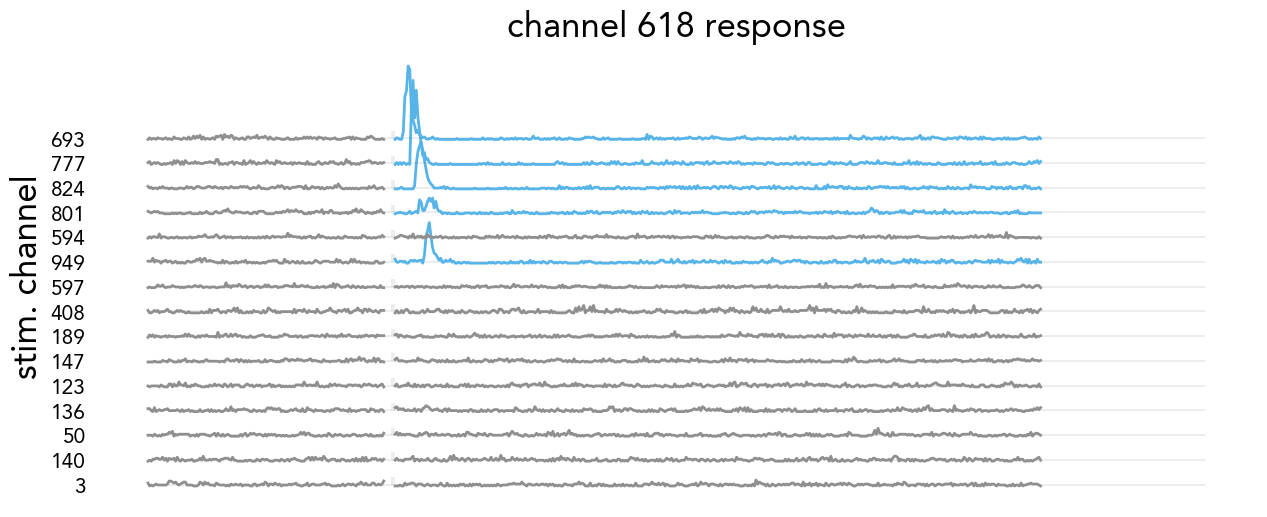

In [170]:
i=0
bin_sz=0.002
i_rec = 618
col_post = [col_u, col_u, col_u, col_u, col_n, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n,][::-1]
sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
plot_traces(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post, col_n, bin_sz=bin_sz, n_ampli=1,#5/(i+1), 
            pre_start=0.7, pre_stop=0.99, post_start=1.004, post_stop=2, stim0=1., stimEnd=1.+0.003,
            figsize=(15,6), outf=path_imgs+f'2.3.1_tracesAlltrial_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms.pdf', show_plot=show_plot)

### 4.2 PLOT TRACES (in pre/post time windows)

Choose a recording channel. For each stim channel, do the mean of the trial spike counts. Sort the plot order by rec-stim distance

In [171]:
col_d = '#0072B2'
col_u = '#56B4E9'
col_n = '#8F8F8F'


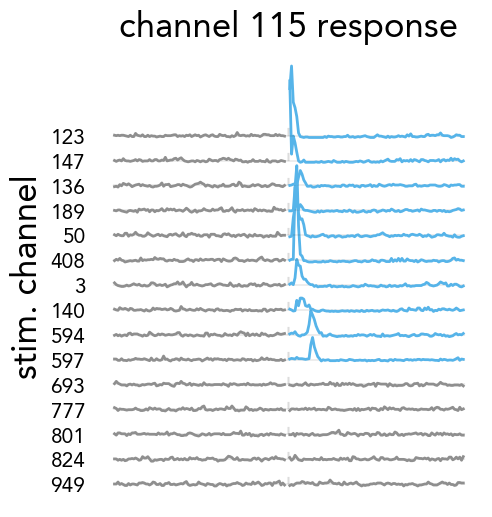

In [172]:
for bin_sz in [0.005]:
    i_rec = 115
    col_post = [col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_u, col_n, col_n, col_n, col_n, col_n,][::-1]
    
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    plot_traces(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post, col_n, bin_sz=bin_sz, n_ampli=1, 
                pre_start=0.5, pre_stop=0.99, post_start=1.004, post_stop=1.005+0.5, stim0=1., stimEnd=1.003,
                figsize=(5,6), outf=path_imgs+f'2.3.2_tracesPrePost_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms.pdf', show_plot=show_plot)
